# Lección 4.2 · Motivos, matrices de peso posicional (PWM) y sequence logos

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-04-msa-motivos-hmm/4.2_motivos_pwm_logos.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 4 — Alineamiento múltiple, motivos y perfiles** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3 horas | Intermedio | Lecciones 1.2 (genes y ORFs), 3.3 (matrices de sustitución, log-odds) y 4.1 |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Explicar** qué es un motivo de secuencia (sitios de unión de factores de transcripción, caja TATA, secuencia de
   Shine-Dalgarno) y por qué una secuencia consenso no basta para describirlo.
2. **Construir a mano y en Python** la cadena completa *sitios alineados → matriz de conteos → frecuencias con
   pseudoconteos → matriz de peso posicional (PWM) en log-odds*.
3. **Calcular** el puntaje de una secuencia con una PWM y **explicar** qué significa un puntaje positivo o negativo.
4. **Medir** la conservación de cada posición con la **entropía de Shannon** y el **contenido de información** (bits),
   incluida la corrección por muestra pequeña.
5. **Dibujar un sequence logo desde cero** con matplotlib, letra por letra.
6. **Programar un muestreador de Gibbs** que descubra un motivo sin saber dónde está, y usarlo para
   **redescubrir la secuencia de Shine-Dalgarno** en los ~4 300 genes de *E. coli* K-12.
7. **Escanear** un genoma completo con una PWM y **decidir** qué coincidencias son significativas comparando con
   secuencias barajadas (p-valor empírico y FDR de Benjamini-Hochberg).

## 🗺️ Mapa de la clase

1. ¿Qué es un motivo? Pequeñas "etiquetas" que las proteínas y los ribosomas saben leer
2. Del consenso a la matriz: conteos, frecuencias y pseudoconteos
3. La matriz de peso posicional (PWM) en log-odds
4. Puntuar una secuencia: sumar pesos
5. ¿Cuánta información hay en cada posición? Entropía y bits
6. 🎨 Un sequence logo construido desde cero
7. 🧪 Datos reales: la región previa al codón de inicio en *E. coli*
8. El problema del descubrimiento de motivos
9. 🎬 El muestreador de Gibbs, paso a paso (datos sintéticos)
10. 🧪 Redescubrir Shine-Dalgarno en *E. coli* y verlo aparear con el ARN ribosomal 16S
11. 🎬 Escanear una secuencia con la PWM
12. ¿Es significativo un puntaje? Secuencias barajadas, p-valores y FDR
13. 🧪 Escaneo del genoma completo: los sitios se acumulan justo antes del codón de inicio
14. Ejercicios, resumen y lecturas

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import gzip, io, time
from collections import Counter
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.textpath import TextPath
from matplotlib.patches import PathPatch, Rectangle, FancyBboxPatch
from matplotlib.font_manager import FontProperties
from matplotlib.transforms import Affine2D

try:
    import Bio
except ImportError:
    %pip install -q biopython
    import Bio
from Bio import SeqIO

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def data_file(name):
    """Busca un archivo del curso en ../data; si no está, lo descarga del repositorio del curso."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return local
    if not os.path.exists(name):
        urllib.request.urlretrieve(f"{RAW}/data/{name}", name)
    return name

BASES = "ACGT"
B_INDEX = {b: i for i, b in enumerate(BASES)}
COMPLEMENT = str.maketrans("ACGT", "TGCA")

def revcomp(seq):
    """Reverso complementario de una secuencia de ADN."""
    return seq.translate(COMPLEMENT)[::-1]

rng = np.random.default_rng(42)          # semilla fija: resultados reproducibles
print("Listo para trabajar con motivos.")

Entorno listo ✔  |  Colab: False
Listo para trabajar con motivos.


## 1. ¿Qué es un motivo? Pequeñas "etiquetas" que las proteínas y los ribosomas saben leer

Un genoma bacteriano tiene millones de letras, y sin embargo la maquinaria de la célula encuentra en segundos los
lugares exactos donde debe actuar: dónde empezar a transcribir, dónde se une un represor, dónde se sienta el
ribosoma para empezar a traducir. Lo logra porque esos lugares llevan **etiquetas cortas de secuencia**, de 5 a 20
nucleótidos, que una proteína (o un ARN) reconoce por contacto químico directo. A esa etiqueta, vista como un patrón
que se repite con pequeñas variaciones en muchos lugares del genoma, la llamamos **motivo**.

Algunos ejemplos clásicos:

| Motivo | Quién lo lee | Consenso típico | Dónde está |
|---|---|---|---|
| **Secuencia de Shine-Dalgarno** (SD) | el extremo 3′ del ARN ribosomal 16S | `AGGAGG` | ~5–10 nt antes del codón de inicio en ARNm bacterianos |
| **Caja −10** (caja de Pribnow) | el factor σ⁷⁰ de la ARN polimerasa | `TATAAT` | ~10 nt antes del inicio de transcripción en bacterias |
| **Caja TATA** | la proteína TBP (eucariotas) | `TATAWAWR` | ~25–30 nt antes del inicio de transcripción |
| Sitio de un **factor de transcripción** (p. ej. LexA, CRP) | la proteína reguladora | depende del factor | promotores de los genes que regula |

La palabra clave es **"con pequeñas variaciones"**. Casi ningún sitio real coincide letra por letra con el consenso.
El ribosoma no necesita un `AGGAGG` perfecto: le basta con que varias bases apareen. Un represor tolera una base
distinta en una posición poco importante, pero no en otra que toca directamente con su aminoácido clave. Por eso
describir un motivo con una sola palabra (el consenso) es como describir la cara de una familia con la foto de un solo
primo: se pierde cuánto varía cada rasgo.

La herramienta que sí captura esa variación es la **matriz de peso posicional** (*position weight matrix*, PWM),
propuesta y estudiada durante los años 80 por Gary Stormo, Tom Schneider y colaboradores, entre otros; y la forma
de dibujarla es el **sequence logo** (Schneider y Stephens, 1990). Ese es el camino de esta clase.

## 2. Del consenso a la matriz: conteos, frecuencias y pseudoconteos

Empecemos con un ejemplo tan pequeño que se puede hacer en papel. Tenemos **8 sitios ya alineados** de 6 nucleótidos,
inspirados en la caja −10 bacteriana (son **didácticos**, escritos para este ejemplo, no sitios reales de un
genoma):

```
TATAAT
TATGAT
TATAAT
GATAAT
TATACT
TAAAAT
TATAAT
TACAAT
```

### Paso 1: la matriz de conteos

Para cada posición (columna) $i$ contamos cuántas veces aparece cada base $b$. Llamamos $n_{b,i}$ a ese número.

| Base | pos 1 | pos 2 | pos 3 | pos 4 | pos 5 | pos 6 |
|---|---|---|---|---|---|---|
| A | 0 | **8** | 1 | **7** | **7** | 0 |
| C | 0 | 0 | 1 | 0 | 1 | 0 |
| G | 1 | 0 | 0 | 1 | 0 | 0 |
| T | **7** | 0 | **6** | 0 | 0 | **8** |

Cada columna suma $N = 8$ (el número de sitios). El consenso `TATAAT` es simplemente la base más frecuente de cada
columna, pero la matriz dice mucho más: la posición 2 es **invariable** (8 de 8 son A) y la posición 3 es la más
**tolerante** (6 T, 1 A, 1 C).

### Paso 2: de conteos a frecuencias… con pseudoconteos

La frecuencia observada sería $n_{b,i}/N$. El problema aparece con los ceros: en la posición 1 nunca vimos una A.
¿Significa que una A allí es **imposible**? Con sólo 8 ejemplos, seguramente no; simplemente no la hemos visto
todavía. Si dejamos la probabilidad en 0, el logaritmo del paso siguiente valdría $-\infty$ y un único cambio de base
descalificaría para siempre a un sitio real.

La solución estándar es sumar un **pseudoconteo**: fingir que, además de los $N$ sitios reales, vimos $\alpha$ sitios
"imaginarios" repartidos según la composición de fondo $q_b$:

$$
p_{b,i} \;=\; \frac{n_{b,i} + \alpha\, q_b}{N + \alpha}
$$

| Símbolo | Significado |
|---|---|
| $n_{b,i}$ | número de sitios con la base $b$ en la posición $i$ |
| $N$ | número total de sitios alineados |
| $q_b$ | frecuencia de fondo de la base $b$ (la composición "normal" del genoma o de la región) |
| $\alpha$ | peso total de los pseudoconteos (aquí $\alpha = 1$: un sitio imaginario en total) |
| $p_{b,i}$ | probabilidad estimada de ver la base $b$ en la posición $i$ **dentro de un sitio** |

**A mano, posición 1** (con $\alpha = 1$ y fondo uniforme $q_b = 0.25$):

$$
p_{T,1} = \frac{7 + 0.25}{8 + 1} = 0.806 \qquad
p_{G,1} = \frac{1 + 0.25}{9} = 0.139 \qquad
p_{A,1} = p_{C,1} = \frac{0 + 0.25}{9} = 0.028
$$

La A pasó de "imposible" a "rara" (2.8 %). Con muchos sitios ($N$ grande) el pseudoconteo casi no influye; con pocos,
nos protege de conclusiones exageradas.

In [2]:
toy_sites = ["TATAAT", "TATGAT", "TATAAT", "GATAAT", "TATACT", "TAAAAT", "TATAAT", "TACAAT"]

def count_matrix(sites):
    """Matriz de conteos 4 x W (filas A, C, G, T) a partir de sitios alineados de igual longitud."""
    W = len(sites[0])
    counts = np.zeros((4, W))
    for s in sites:
        for i, b in enumerate(s):
            counts[B_INDEX[b], i] += 1
    return counts

def frequencies(counts, background=np.full(4, 0.25), alpha=1.0):
    """Frecuencias por columna con pseudoconteos repartidos según el fondo."""
    N = counts.sum(axis=0)                       # sitios por columna
    return (counts + alpha * background[:, None]) / (N + alpha)

toy_counts = count_matrix(toy_sites)
toy_freq = frequencies(toy_counts)
cols = [f"pos {i+1}" for i in range(toy_counts.shape[1])]
display(pd.DataFrame(toy_counts.astype(int), index=list(BASES), columns=cols).style.set_caption("Conteos n(b,i)"))
display(pd.DataFrame(toy_freq, index=list(BASES), columns=cols).round(3).style.set_caption("Frecuencias p(b,i) con α = 1"))

,pos 1,pos 2,pos 3,pos 4,pos 5,pos 6
A,0,8,1,7,7,0
C,0,0,1,0,1,0
G,1,0,0,1,0,0
T,7,0,6,0,0,8


,pos 1,pos 2,pos 3,pos 4,pos 5,pos 6
A,0.028000,0.917000,0.139000,0.806000,0.806000,0.028000
C,0.028000,0.028000,0.139000,0.028000,0.139000,0.028000
G,0.139000,0.028000,0.028000,0.139000,0.028000,0.028000
T,0.806000,0.028000,0.694000,0.028000,0.028000,0.917000


> ✅ **Compruebe su comprensión.** Con $\alpha = 1$ y fondo uniforme, ¿cuánto vale $p_{A,2}$ (la columna invariable)?
> ¿Y si hubiéramos tenido 80 sitios, todos con A en la posición 2? *(Respuestas: $8.25/9 = 0.917$ y
> $80.25/81 = 0.991$: con más datos el pseudoconteo pesa menos.)*

## 3. La matriz de peso posicional (PWM) en log-odds

Una frecuencia de 0.8 para la T, ¿es mucho o poco? Depende de lo común que sea la T **en general**. Si el genoma
fuera 80 % T, ver 80 % de T en un sitio no diría nada. Por eso la PWM compara cada probabilidad con la del fondo, con
el mismo razonamiento de *log-odds* que ya usamos en la Lección 3.3 para construir BLOSUM:

$$
w_{b,i} \;=\; \log_2 \frac{p_{b,i}}{q_b}
$$

| Símbolo | Significado |
|---|---|
| $w_{b,i}$ | **peso** de la base $b$ en la posición $i$ (en bits, porque usamos logaritmo en base 2) |
| $p_{b,i}$ | probabilidad de $b$ en la posición $i$ bajo el **modelo de sitio** |
| $q_b$ | probabilidad de $b$ bajo el **modelo de fondo** (secuencia "cualquiera") |

Lectura del signo:

* $w > 0$: esa base es **más frecuente** en los sitios que en el fondo → vota "esto parece un sitio".
* $w = 0$: igual de frecuente en ambos → no aporta evidencia.
* $w < 0$: **menos frecuente** en los sitios → vota "esto no parece un sitio".

**A mano, posición 1** ($q_b = 0.25$):

$$
w_{T,1} = \log_2\frac{0.806}{0.25} = \log_2 3.22 = +1.69 \qquad
w_{G,1} = \log_2\frac{0.139}{0.25} = -0.85 \qquad
w_{A,1} = w_{C,1} = \log_2\frac{0.028}{0.25} = -3.17
$$

Una T en la posición 1 hace al sitio $2^{1.69} \approx 3.2$ veces más probable bajo el modelo de sitio que bajo el de
fondo; una A lo hace 9 veces **menos** probable ($2^{-3.17} \approx 1/9$).

In [3]:
def pwm_log_odds(freq, background=np.full(4, 0.25)):
    """PWM en bits: log2(p / q) para cada base y posición."""
    return np.log2(freq / background[:, None])

toy_pwm = pwm_log_odds(toy_freq)
pd.DataFrame(toy_pwm, index=list(BASES), columns=cols).round(2)

,pos 1,pos 2,pos 3,pos 4,pos 5,pos 6
A,-3.17,1.87,-0.85,1.69,1.69,-3.17
C,-3.17,-3.17,-0.85,-3.17,-0.85,-3.17
G,-0.85,-3.17,-3.17,-0.85,-3.17,-3.17
T,1.69,-3.17,1.47,-3.17,-3.17,1.87


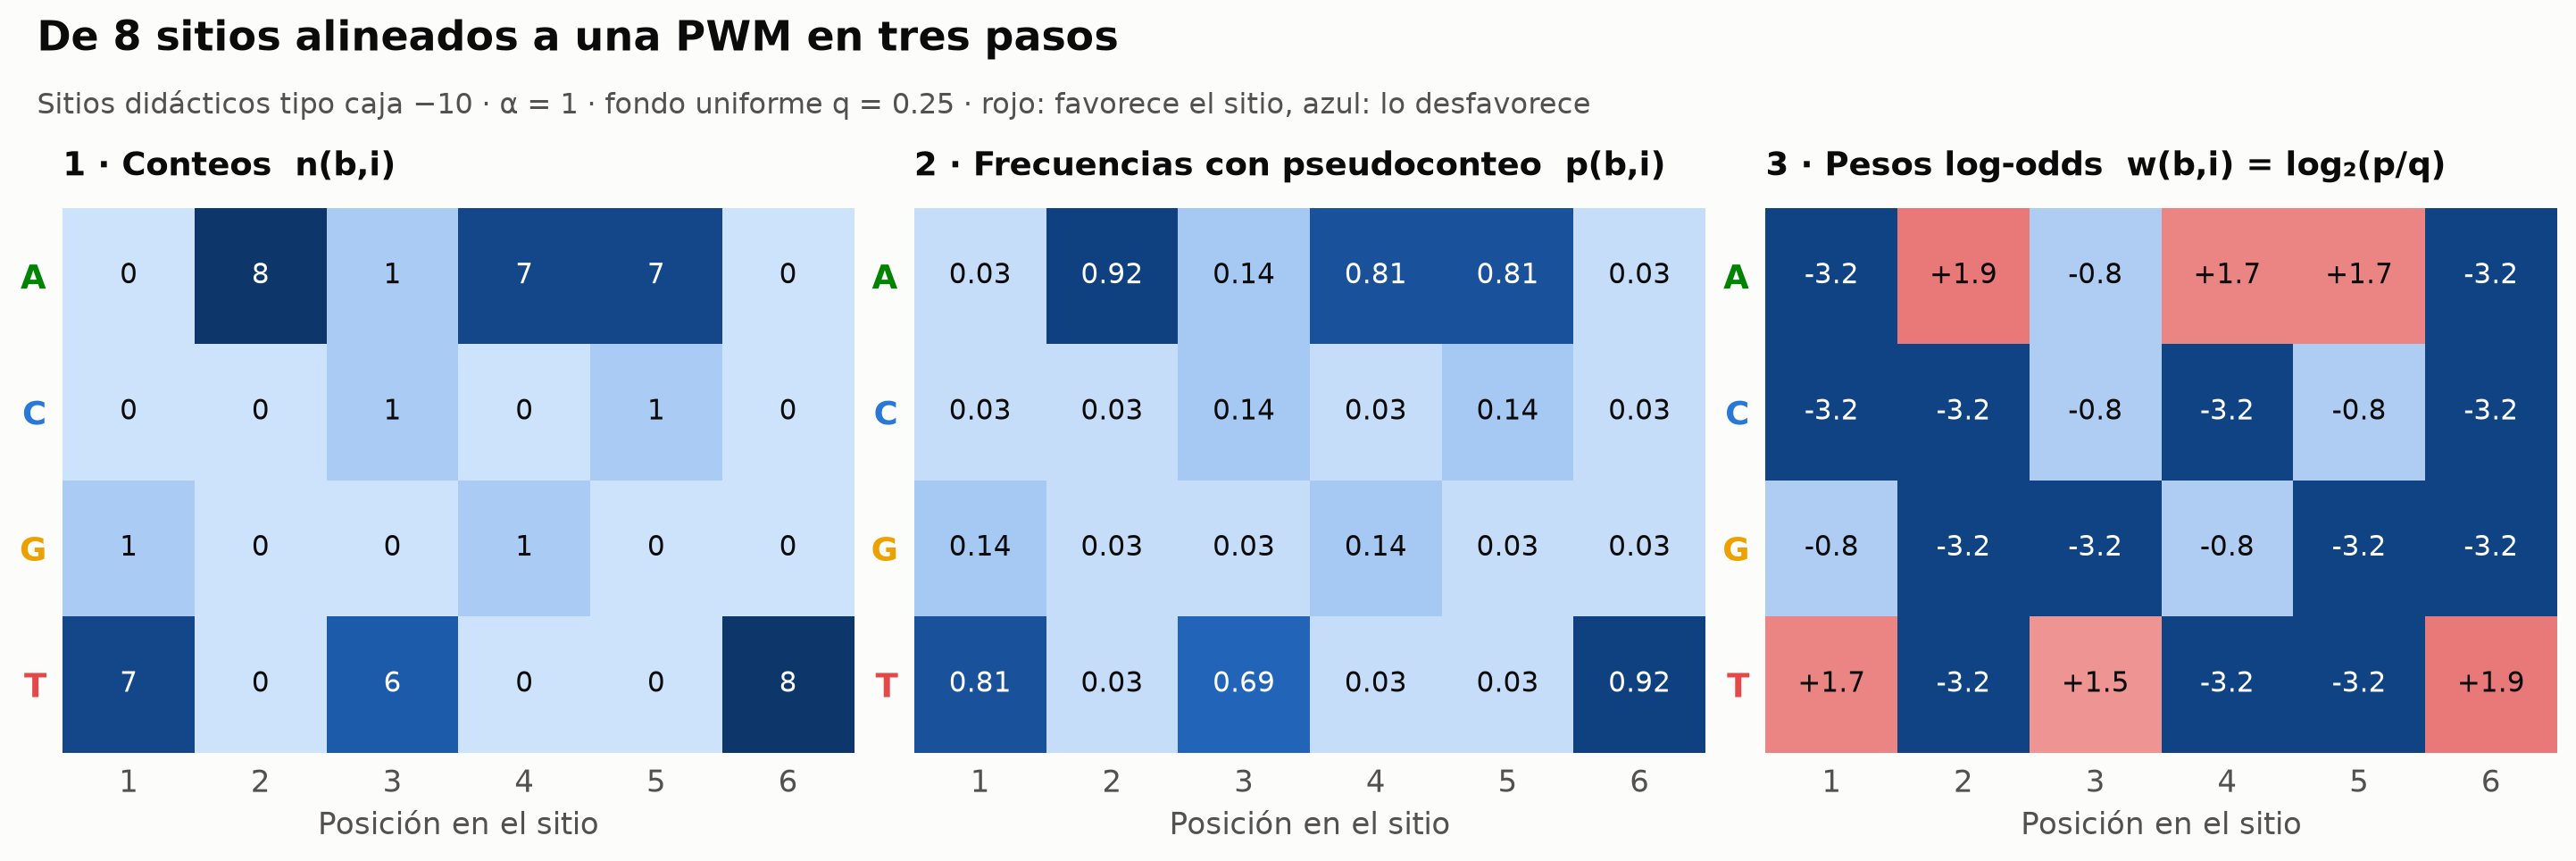

In [4]:
def draw_matrix(ax, M, fmt="{:+.2f}", cmap=ec.CMAP_DIV, vmax=None, labels=True, fs=10):
    """Dibuja una matriz 4 x W como mapa de calor con el valor escrito en cada celda."""
    vmax = vmax or np.abs(M).max()
    ax.imshow(M, cmap=cmap, vmin=-vmax if cmap is ec.CMAP_DIV else 0, vmax=vmax, aspect="auto")
    for (b, i), v in np.ndenumerate(M):
        shade = abs(v) / vmax if cmap is ec.CMAP_DIV else v / vmax
        ax.text(i, b, fmt.format(v), ha="center", va="center", fontsize=fs,
                color="white" if shade > 0.6 else ec.INK)
    ax.set_yticks(range(4)); ax.set_yticklabels(list(BASES))
    for t, b in zip(ax.get_yticklabels(), BASES):
        t.set_color(ec.NUC_COLORS[b]); t.set_fontweight("bold"); t.set_fontsize(12)
    ax.set_xticks(range(M.shape[1])); ax.set_xticklabels([str(i + 1) for i in range(M.shape[1])])
    ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
draw_matrix(axes[0], toy_counts, fmt="{:.0f}", cmap=ec.CMAP_SEQ, vmax=8)
axes[0].set_title("1 · Conteos  n(b,i)", fontsize=12)
draw_matrix(axes[1], toy_freq, fmt="{:.2f}", cmap=ec.CMAP_SEQ, vmax=1)
axes[1].set_title("2 · Frecuencias con pseudoconteo  p(b,i)", fontsize=12)
draw_matrix(axes[2], toy_pwm, fmt="{:+.1f}", cmap=ec.CMAP_DIV, vmax=3.2)
axes[2].set_title("3 · Pesos log-odds  w(b,i) = log₂(p/q)", fontsize=12)
for ax in axes:
    ax.set_xlabel("Posición en el sitio")
ec.fig_title(fig, "De 8 sitios alineados a una PWM en tres pasos",
             "Sitios didácticos tipo caja −10 · α = 1 · fondo uniforme q = 0.25 · rojo: favorece el sitio, azul: lo desfavorece")
plt.show()

> 🔎 **Qué observamos.** Los ceros de la matriz de conteos se convierten en frecuencias pequeñas pero no nulas, y en
> pesos muy negativos (azul intenso, −3.2 bits). La base del consenso de cada columna recibe el peso más alto
> (rojo). La posición 3 es la única donde una desviación del consenso "cuesta poco" (−0.85 bits para A o C), lo que
> refleja que en los datos fue la más variable.

## 4. Puntuar una secuencia: sumar pesos

Con la PWM en la mano, evaluar una secuencia candidata $x = x_1 x_2 \dots x_W$ de la misma longitud que el motivo es
tan simple como **leer un peso por columna y sumarlos**:

$$
S(x) \;=\; \sum_{i=1}^{W} w_{x_i,\,i} \;=\; \log_2 \frac{P(x \mid \text{sitio})}{P(x \mid \text{fondo})}
$$

| Símbolo | Significado |
|---|---|
| $x_i$ | la base de la secuencia candidata en la posición $i$ |
| $w_{x_i, i}$ | el peso de esa base en esa columna (una celda de la PWM) |
| $W$ | longitud del motivo (número de columnas) |
| $S(x)$ | puntaje total, en bits: el logaritmo de cuántas veces más probable es $x$ como sitio que como fondo |

La segunda igualdad es la razón de fondo: si suponemos que las posiciones son **independientes**, la probabilidad de
toda la secuencia es el producto de las probabilidades de cada columna, y el logaritmo de un producto es una suma.
Es la misma lógica que en un alineamiento sin huecos con BLOSUM (Lección 3.3), sólo que aquí la "matriz de
sustitución" cambia de columna a columna.

### Ejemplo a mano

| Secuencia | pos 1 | pos 2 | pos 3 | pos 4 | pos 5 | pos 6 | $S(x)$ |
|---|---|---|---|---|---|---|---|
| `TATAAT` (consenso) | T: +1.69 | A: +1.87 | T: +1.47 | A: +1.69 | A: +1.69 | T: +1.87 | **+10.29** |
| `TACAAT` | +1.69 | +1.87 | C: −0.85 | +1.69 | +1.69 | +1.87 | **+7.97** |
| `GATGCT` | G: −0.85 | +1.87 | +1.47 | G: −0.85 | C: −0.85 | +1.87 | **+2.68** |
| `CCGCGG` | −3.17 | −3.17 | −3.17 | −3.17 | −3.17 | −3.17 | **−19.02** |

`TATAAT` es $2^{10.29} \approx 1\,250$ veces más probable bajo el modelo de sitio que bajo el fondo. `GATGCT`, con
tres diferencias, todavía tiene puntaje positivo, pero sólo $2^{2.68} \approx 6$ veces: es una evidencia débil.

In [5]:
def score_site(seq, pwm):
    """Puntaje log-odds (bits) de una secuencia de longitud W con una PWM 4 x W."""
    return sum(pwm[B_INDEX[b], i] for i, b in enumerate(seq))

for s in ["TATAAT", "TACAAT", "GATGCT", "CCGCGG"]:
    print(f"{s}:  S = {score_site(s, toy_pwm):+7.2f} bits   →   {2 ** score_site(s, toy_pwm):10.3g} veces más probable como sitio")
print(f"\nPuntaje máximo posible: {toy_pwm.max(axis=0).sum():+.2f}   ·   mínimo posible: {toy_pwm.min(axis=0).sum():+.2f}")

TATAAT:  S =  +10.29 bits   →     1.25e+03 veces más probable como sitio
TACAAT:  S =   +7.97 bits   →          250 veces más probable como sitio
GATGCT:  S =   +2.68 bits   →          6.4 veces más probable como sitio
CCGCGG:  S =  -19.02 bits   →     1.88e-06 veces más probable como sitio

Puntaje máximo posible: +10.29   ·   mínimo posible: -19.02


> 🤔 **Antes de ejecutar, prediga.** Si puntuamos **las 4 096** secuencias posibles de 6 letras, ¿qué fracción cree que
> tendrá un puntaje positivo? ¿La mitad? ¿Un 10 %? ¿Menos del 1 %?

Hexámeros con S > 0: 250 de 4096  (6.1%)


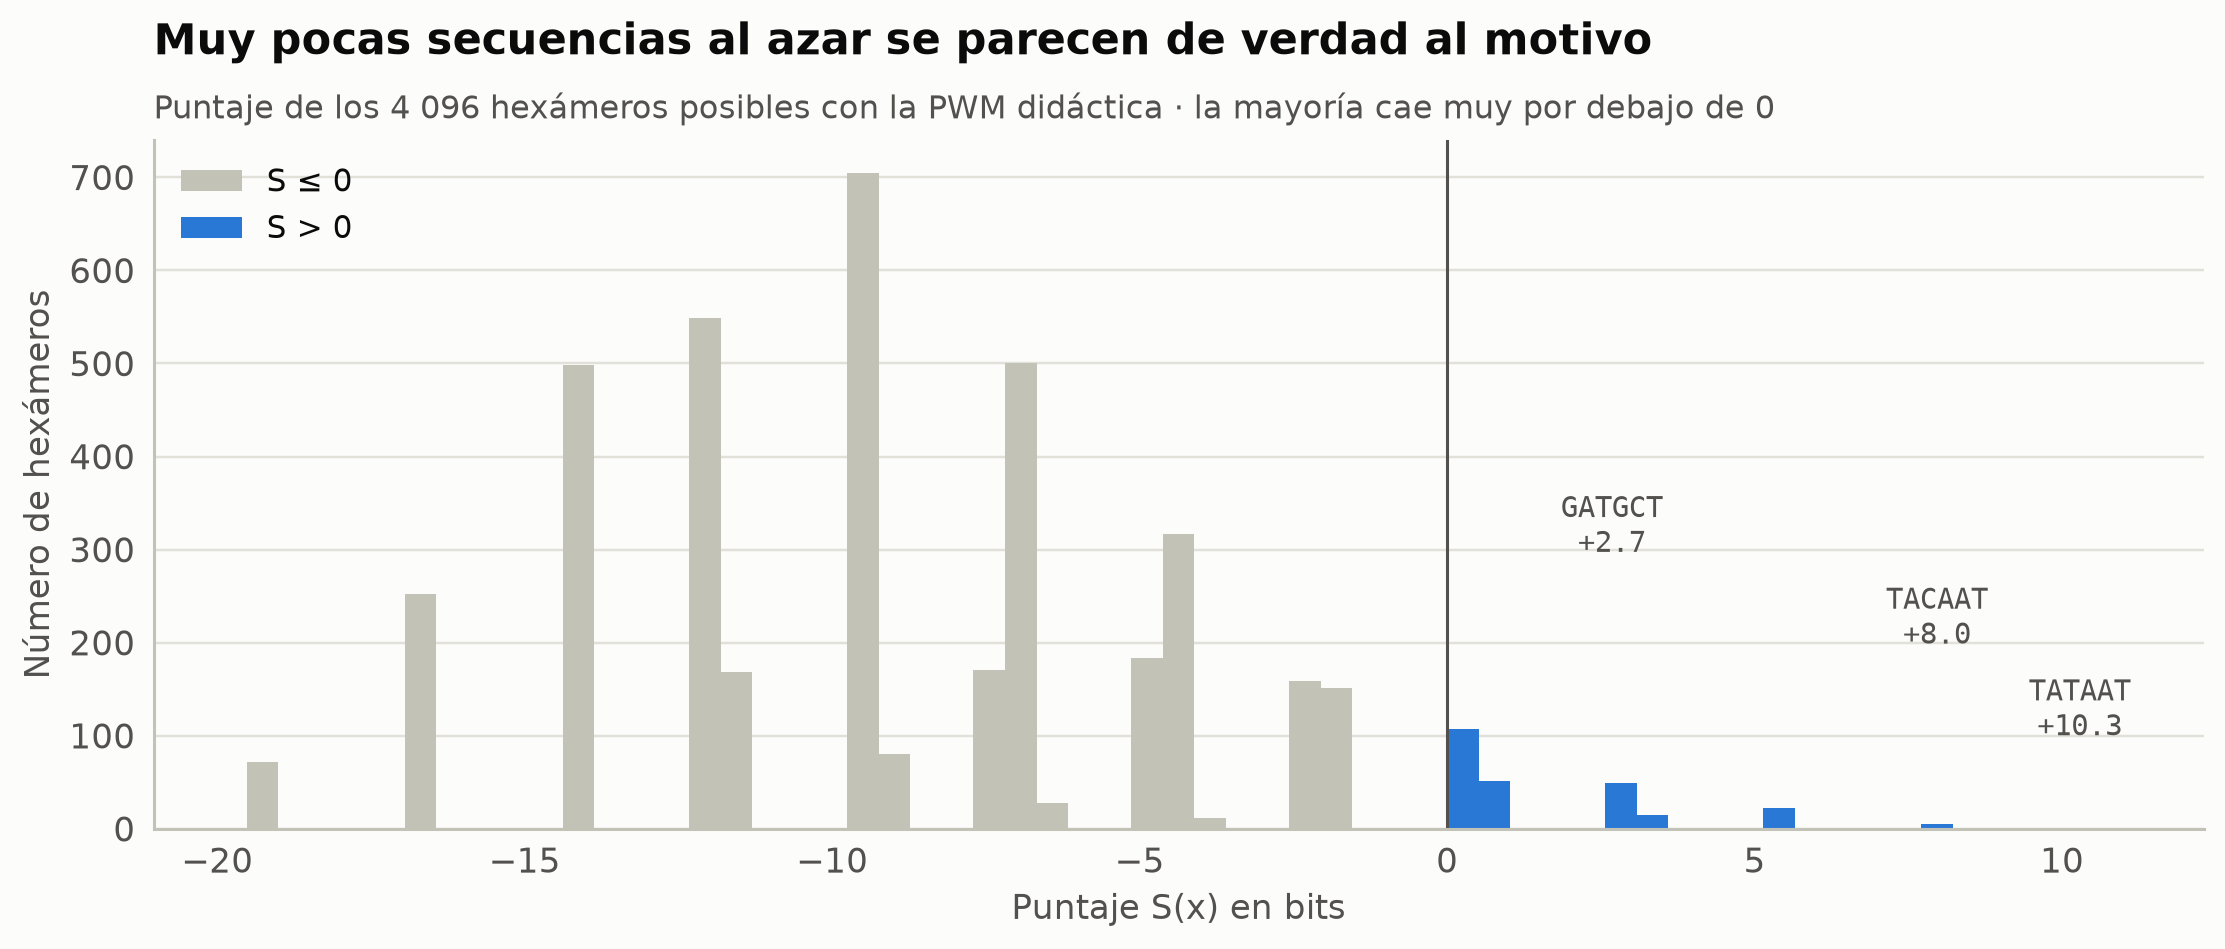

In [6]:
from itertools import product
all_hexamers = ["".join(p) for p in product(BASES, repeat=6)]
all_scores = np.array([score_site(s, toy_pwm) for s in all_hexamers])
print(f"Hexámeros con S > 0: {np.sum(all_scores > 0)} de {len(all_scores)}  ({np.mean(all_scores > 0):.1%})")

fig, ax = plt.subplots(figsize=(10, 4.2))
bins = np.linspace(all_scores.min() - 0.5, all_scores.max() + 0.5, 60)
ax.hist(all_scores[all_scores <= 0], bins=bins, color=ec.BASELINE, label="S ≤ 0")
ax.hist(all_scores[all_scores > 0], bins=bins, color=ec.BLUE, label="S > 0")
for s, dy in [("TATAAT", 30), ("TACAAT", 60), ("GATGCT", 90)]:
    v = score_site(s, toy_pwm)
    ax.annotate(f"{s}\n{v:+.1f}", (v, 2), xytext=(0, dy), textcoords="offset points", ha="center", fontsize=9.5,
                family="DejaVu Sans Mono", color=ec.INK_2, arrowprops=dict(arrowstyle="-", color=ec.MUTED))
ax.axvline(0, color=ec.INK_2, lw=1)
ax.set_xlabel("Puntaje S(x) en bits"); ax.set_ylabel("Número de hexámeros")
ax.legend(loc="upper left")
ec.title(ax, "Muy pocas secuencias al azar se parecen de verdad al motivo",
         "Puntaje de los 4 096 hexámeros posibles con la PWM didáctica · la mayoría cae muy por debajo de 0")
plt.show()

> 🔎 **Qué observamos.** Sólo alrededor del 6 % de los hexámeros posibles obtiene un puntaje positivo, y apenas unas
> decenas superan los +5 bits. La distribución tiene "escalones" porque cada columna sólo admite unos pocos valores de peso.
> Esta misma distribución, calculada sobre secuencias de fondo, será la base para decidir más adelante si un
> puntaje es **significativo**.

## 5. ¿Cuánta información hay en cada posición? Entropía y bits

No todas las columnas de un motivo importan igual. En la posición 2 del ejemplo, la proteína "exige" una A; en la
posición 3 es más permisiva. ¿Cómo medir esa exigencia con un solo número? Con la **entropía de Shannon**, que mide
la **incertidumbre** sobre qué base aparecerá:

$$
H_i \;=\; -\sum_{b \in \{A,C,G,T\}} f_{b,i}\,\log_2 f_{b,i}
\qquad\qquad
IC_i \;=\; \log_2 4 \;-\; H_i \;=\; 2 - H_i
$$

| Símbolo | Significado |
|---|---|
| $f_{b,i}$ | frecuencia observada de la base $b$ en la columna $i$ (aquí **sin** pseudoconteo: $n_{b,i}/N$) |
| $H_i$ | entropía de la columna, en bits: 0 si siempre hay la misma base, 2 si las cuatro son igual de frecuentes |
| $\log_2 4 = 2$ | la incertidumbre máxima con 4 letras equiprobables (dos preguntas de sí o no bastan para adivinar una base) |
| $IC_i$ | **contenido de información** (*information content*): cuánta incertidumbre elimina saber que estamos en un sitio |
| $0 \log_2 0$ | se toma igual a 0 por convención |

Piense en adivinar una base con preguntas de sí/no: *"¿es purina?"*, *"¿es A?"*. Sin información previa necesita
2 preguntas. Si la columna siempre tiene A, no necesita ninguna: la columna le "regaló" 2 bits.

### Ejemplo a mano

* **Posición 2** (8 A): $H = -1 \cdot \log_2 1 = 0$ → $IC = 2$ bits (conservación total).
* **Posición 1** (7 T, 1 G): $H = -(0.875 \log_2 0.875 + 0.125 \log_2 0.125) = 0.169 + 0.375 = 0.544$ →
  $IC = 1.456$ bits.
* **Posición 3** (6 T, 1 A, 1 C): $H = -(0.75 \log_2 0.75 + 2 \times 0.125 \log_2 0.125) = 0.311 + 0.75 = 1.061$ →
  $IC = 0.939$ bits.

### La corrección por muestra pequeña

Con pocos sitios, la entropía estimada **sale sistemáticamente más baja** de lo que es en realidad: con sólo 8
ejemplos es fácil que una base rara no aparezca nunca, y la columna parece más conservada de lo que es. Schneider y
colaboradores (1986) propusieron restar una corrección $e(N)$; para $N$ no demasiado pequeño, una buena aproximación es:

$$
e(N) \;\approx\; \frac{s - 1}{2 \ln 2 \cdot N}
\qquad\qquad
IC_i^{\text{corr}} \;=\; \max\bigl(0,\; 2 - H_i - e(N)\bigr)
$$

| Símbolo | Significado |
|---|---|
| $s$ | tamaño del alfabeto ($s = 4$ para ADN) |
| $N$ | número de sitios |
| $e(N)$ | sesgo esperado de la entropía por tener sólo $N$ muestras, en bits |

Con $N = 8$: $e(8) \approx 3 / (2 \times 0.693 \times 8) = 0.27$ bits, una corrección nada despreciable. Con 1 000 sitios
sería de sólo 0.002 bits. Recortamos en 0 para no dibujar alturas negativas.

In [7]:
def column_entropy(counts):
    """Entropía de Shannon (bits) de cada columna de una matriz de conteos."""
    f = counts / counts.sum(axis=0)
    with np.errstate(divide="ignore", invalid="ignore"):
        terms = np.where(f > 0, f * np.log2(f), 0.0)
    return -terms.sum(axis=0)

def information_content(counts, correct=True):
    """Contenido de información por columna (bits), con la corrección de muestra pequeña opcional."""
    N = counts.sum(axis=0)
    ic = 2.0 - column_entropy(counts)
    if correct:
        ic = ic - 3.0 / (2 * np.log(2) * N)
    return np.clip(ic, 0, 2)

pd.DataFrame({"H (bits)": column_entropy(toy_counts),
              "IC sin corregir": information_content(toy_counts, correct=False),
              "IC corregido": information_content(toy_counts)}, index=cols).round(3).T

,pos 1,pos 2,pos 3,pos 4,pos 5,pos 6
H (bits),0.544,-0.000,1.061,0.544,0.544,-0.000
IC sin corregir,1.456,2.000,0.939,1.456,1.456,2.000
IC corregido,1.186,1.729,0.668,1.186,1.186,1.729


> ✅ **Compruebe su comprensión.** Una columna tiene 50 % A y 50 % G. ¿Cuál es su entropía y su contenido de
> información? *(Respuesta: $H = 1$ bit, $IC = 1$ bit: sabemos que es una purina, pero no cuál.)*

El contenido de información total del motivo, $\sum_i IC_i$, tiene una lectura muy concreta: un sitio con $R$ bits de
información aparece al azar aproximadamente **una vez cada $2^{R}$ posiciones** de secuencia uniforme. Nuestro
motivo didáctico tiene unos 9 bits (sin corregir): uno cada ~600 posiciones. Schneider y colaboradores (1986)
observaron que, para muchos sitios reales, esa información es la justa para que el sitio sea reconocible en el tamaño
del genoma.

## 6. 🎨 Un sequence logo construido desde cero

El **sequence logo** (Schneider y Stephens, 1990) dibuja toda esta información de una sola mirada:

* cada columna es una **pila de letras**;
* la **altura total** de la pila es el contenido de información $IC_i$ (en bits, de 0 a 2);
* dentro de la pila, cada letra ocupa una altura **proporcional a su frecuencia**: $h_{b,i} = f_{b,i} \cdot IC_i$;
* las letras se apilan de la menos frecuente (abajo) a la más frecuente (arriba), de modo que el consenso queda
  en la cima.

Hay bibliotecas que lo hacen (WebLogo, `logomaker`), pero construirlo nosotros deja claro que no hay magia: cada
letra es una **forma vectorial** (un `TextPath` de matplotlib) que estiramos para que ocupe exactamente el rectángulo
que le corresponde.

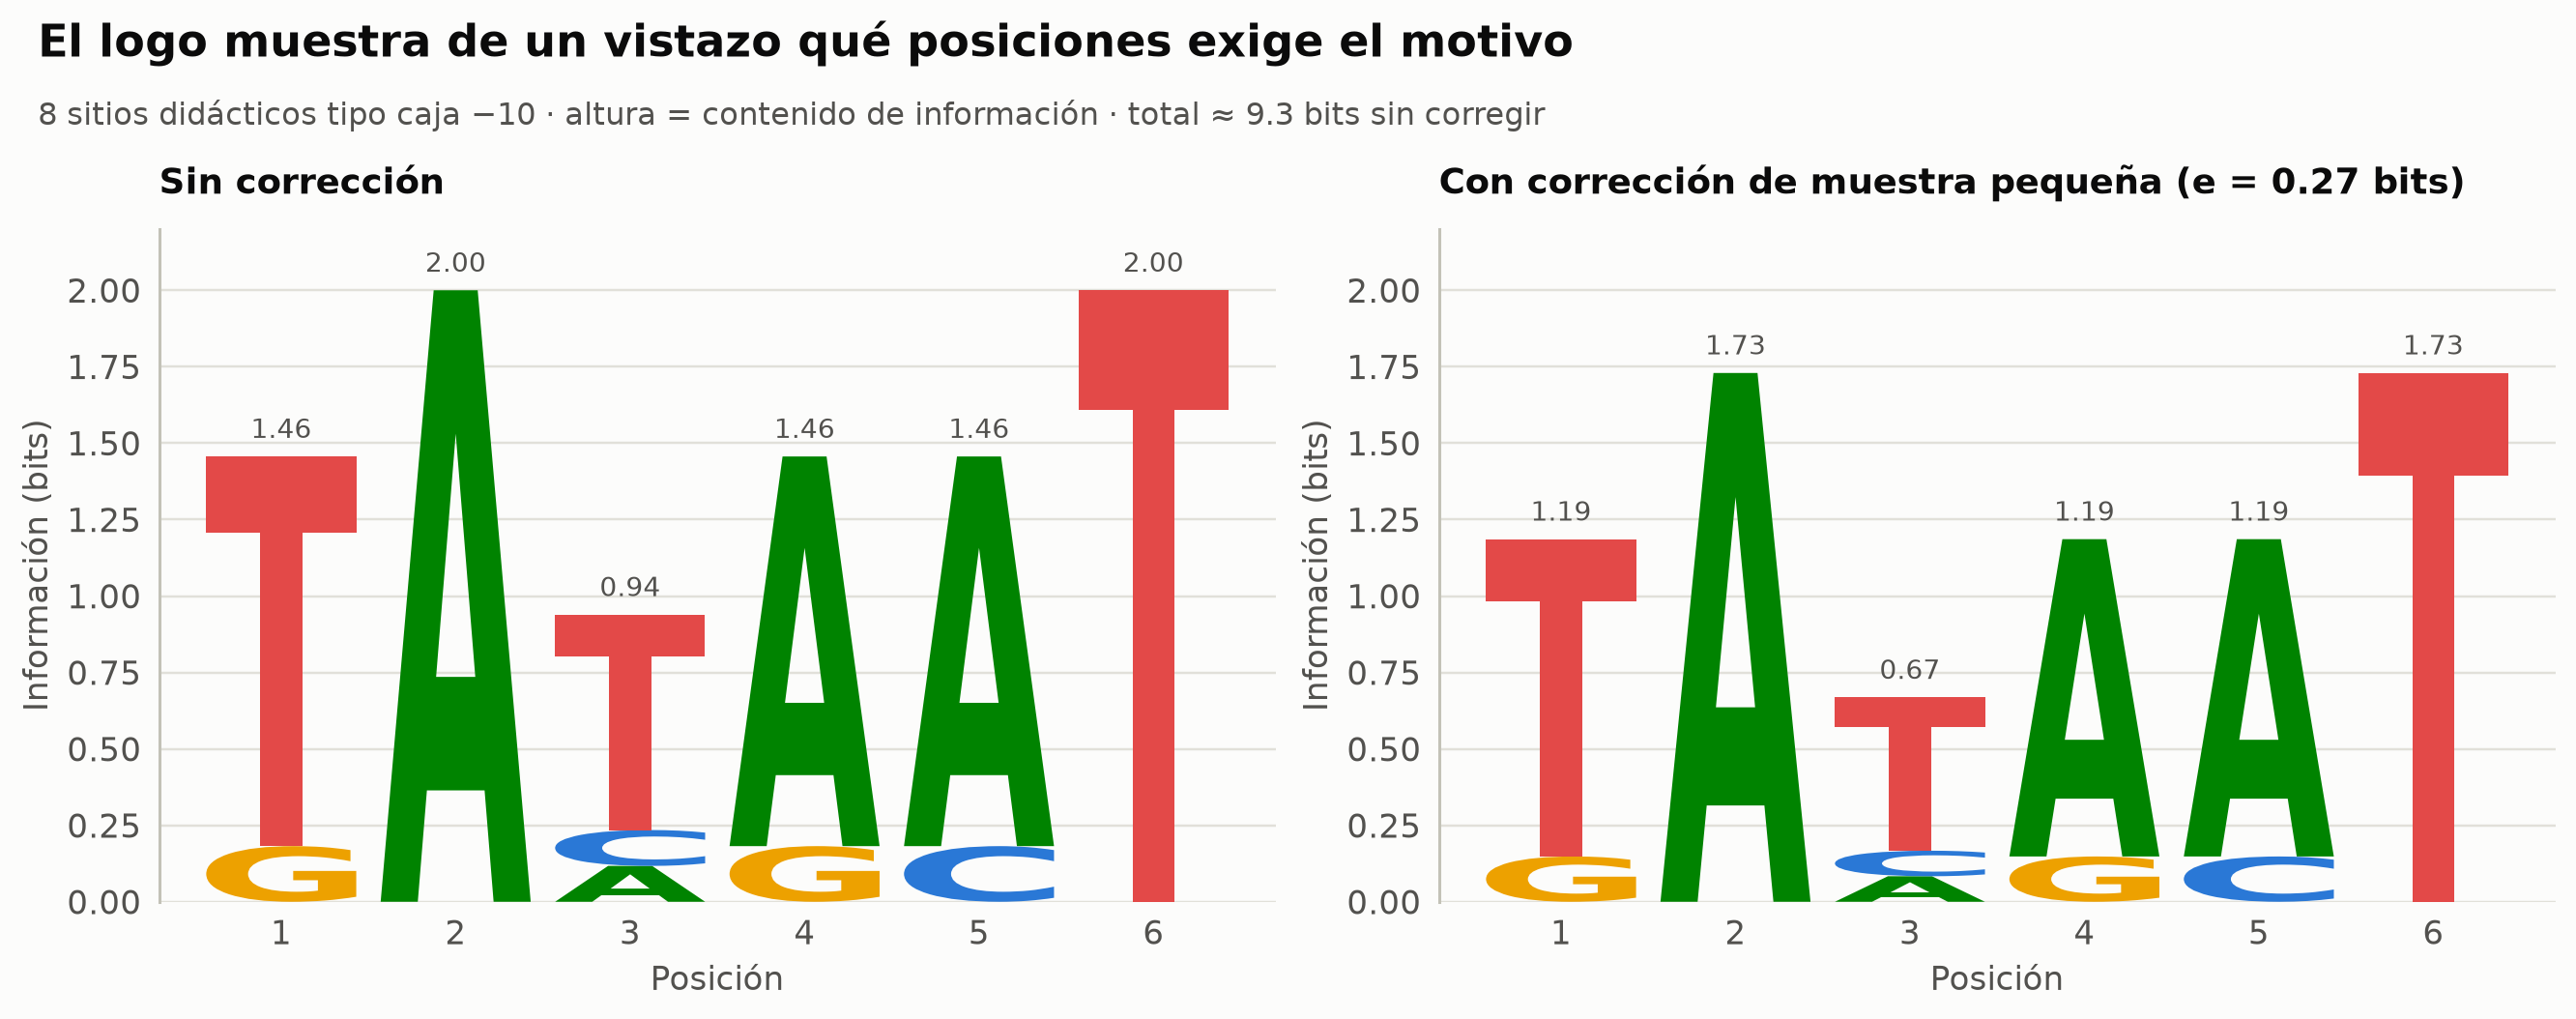

In [8]:
_FONT = FontProperties(family="DejaVu Sans", weight="bold")
_GLYPHS = {}

def _glyph(letter):
    """Contorno vectorial de una letra, normalizado a un cuadrado de 1 x 1."""
    if letter not in _GLYPHS:
        path = TextPath((0, 0), letter, size=1, prop=_FONT)
        ext = path.get_extents()
        _GLYPHS[letter] = (path, ext)
    return _GLYPHS[letter]

def draw_letter(ax, letter, x, y, width, height, color, alpha=1.0):
    """Dibuja una letra que ocupa exactamente el rectángulo [x, x+width] x [y, y+height] (unidades de datos)."""
    if height <= 1e-4:
        return
    path, ext = _glyph(letter)
    tr = (Affine2D().translate(-ext.x0, -ext.y0)
          .scale(width / ext.width, height / ext.height)
          .translate(x, y))
    ax.add_patch(PathPatch(tr.transform_path(path), facecolor=color, edgecolor="none", alpha=alpha))

def draw_logo(ax, counts, correct=True, positions=None, ylim=2.0, letter_width=0.86, xlabel="Posición",
              highlight=None):
    """Sequence logo desde cero: altura de la pila = IC (bits); cada letra ∝ su frecuencia."""
    W = counts.shape[1]
    positions = list(range(1, W + 1)) if positions is None else list(positions)
    f = counts / counts.sum(axis=0)
    ic = information_content(counts, correct=correct)
    if highlight is not None:                       # banda de fondo para señalar una región
        ax.axvspan(highlight[0] - 0.5, highlight[1] + 0.5, color=ec.YELLOW, alpha=0.12, lw=0)
    for i in range(W):
        y = 0.0
        for b in np.argsort(f[:, i]):              # de la menos a la más frecuente
            h = f[b, i] * ic[i]
            draw_letter(ax, BASES[b], i + 1 - letter_width / 2, y, letter_width, h, ec.NUC_COLORS[BASES[b]])
            y += h
    ax.set_xlim(0.3, W + 0.7); ax.set_ylim(0, ylim)
    step = 1 if W <= 25 else 2
    ax.set_xticks(range(1, W + 1, step)); ax.set_xticklabels([str(p) for p in positions][::step])
    ax.set_ylabel("Información (bits)"); ax.set_xlabel(xlabel)
    ax.grid(axis="y", visible=True); ax.spines["bottom"].set_visible(False)
    return ic

fig, axes = plt.subplots(1, 2, figsize=(12, 4), width_ratios=[1, 1])
ic_raw = draw_logo(axes[0], toy_counts, correct=False)
axes[0].set_title("Sin corrección", fontsize=12)
ic_cor = draw_logo(axes[1], toy_counts, correct=True)
axes[1].set_title(f"Con corrección de muestra pequeña (e = {3 / (2 * np.log(2) * 8):.2f} bits)", fontsize=12)
for ax, ic in zip(axes, [ic_raw, ic_cor]):
    for i, v in enumerate(ic):
        ax.text(i + 1, v + 0.04, f"{v:.2f}", ha="center", va="bottom", fontsize=9, color=ec.INK_2)
    ax.set_ylim(0, 2.2)
ec.fig_title(fig, "El logo muestra de un vistazo qué posiciones exige el motivo",
             f"8 sitios didácticos tipo caja −10 · altura = contenido de información · total ≈ {ic_raw.sum():.1f} bits sin corregir")
plt.show()

> 🔎 **Qué observamos.** Las posiciones 2 y 6 alcanzan el techo de 2 bits (letras enormes, sin rivales). En la
> posición 3 la T sigue ganando, pero la pila es más baja y asoman pequeñas A y C: es la posición "permisiva". Con
> sólo 8 sitios la corrección rebaja todas las pilas unos 0.27 bits: con pocos datos debemos ser más prudentes al
> afirmar que una posición está conservada.

Observe la diferencia entre la **PWM** y el **logo**: la PWM es una herramienta para **calcular** (pesos que se
suman), el logo es una herramienta para **mirar** (cuánto importa cada posición y qué base prefiere). Ambos salen de
la misma matriz de conteos.

## 7. 🧪 Datos reales: la región previa al codón de inicio en *E. coli*

Pasemos a un motivo real y famoso. En 1974, John Shine y Lynn Dalgarno notaron que el extremo 3′ del ARN ribosomal
16S de *E. coli* termina en `…ACCUCCUUA-3′` y propusieron que esa región se **aparea por complementariedad** con una
secuencia rica en purinas (`AGGAGG`) situada poco antes del codón de inicio de los ARN mensajeros. Así el ribosoma
"sabe" dónde empezar a traducir. Hoy la llamamos **secuencia de Shine-Dalgarno** (SD).

Vamos a comprobarlo con datos: el genoma de referencia de *E. coli* K-12 MG1655 (`NC_000913.3`) y la anotación de sus
genes que publica el NCBI en el mismo registro GenBank. Para cada uno de los ~4 300 genes codificantes (CDS) tomamos
los **20 nucleótidos anteriores al codón de inicio** más el propio codón, respetando la hebra: si el gen está en la
hebra − usamos el reverso complementario.

> 📦 **Datos.** `NC_000913.3.fasta.gz` (genoma) y `NC_000913.3_cds.tsv.gz` (tabla con las coordenadas de los CDS y
> de los ARN ribosomales, extraída del GenBank de RefSeq). Si no están en `../data`, se descargan del repositorio del
> curso y, como último recurso, se reconstruyen desde el NCBI (el GenBank completo pesa ~11 MB).

In [9]:
ACC = "NC_000913.3"

def load_genome():
    """Genoma de E. coli K-12 (FASTA comprimido del curso; si falla, NCBI)."""
    try:
        with gzip.open(data_file(f"{ACC}.fasta.gz"), "rt") as fh:
            return str(SeqIO.read(fh, "fasta").seq).upper()
    except Exception:
        url = f"https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id={ACC}&rettype=fasta&retmode=text"
        return str(SeqIO.read(io.StringIO(urllib.request.urlopen(url).read().decode()), "fasta").seq).upper()

def load_annotation():
    """Coordenadas de CDS y rRNA (tabla del curso; si falla, se reconstruye desde el GenBank del NCBI)."""
    try:
        return pd.read_csv(data_file(f"{ACC}_cds.tsv.gz"), sep="\t", comment="#")
    except Exception:
        url = f"https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id={ACC}&rettype=gbwithparts&retmode=text"
        rec = SeqIO.read(io.StringIO(urllib.request.urlopen(url).read().decode()), "genbank")
        rows = []
        for f in rec.features:
            if f.type in ("CDS", "rRNA") and "pseudo" not in f.qualifiers and len(f.location.parts) == 1:
                q = f.qualifiers
                rows.append((f.type, q.get("locus_tag", [""])[0], q.get("gene", [""])[0], int(f.location.start) + 1,
                             int(f.location.end), "+" if f.location.strand == 1 else "-", q.get("product", [""])[0]))
        return pd.DataFrame(rows, columns=["type", "locus_tag", "gene", "start", "end", "strand", "product"])

genome = load_genome()
G_LEN = len(genome)
annot = load_annotation()
cds = annot[annot["type"] == "CDS"].reset_index(drop=True)
print(f"Genoma: {G_LEN:,} pb · CDS anotados: {len(cds):,} · rRNA: {(annot['type'] == 'rRNA').sum()}")
cds.head()

Genoma: 4,641,652 pb · CDS anotados: 4,297 · rRNA: 22


,type,locus_tag,gene,start,end,strand,product
0,CDS,b0001,thrL,190,255,+,thr operon leader peptide
1,CDS,b0002,thrA,337,2799,+,fused aspartate kinase/homoserine dehydrogenase 1
2,CDS,b0003,thrB,2801,3733,+,homoserine kinase
3,CDS,b0004,thrC,3734,5020,+,threonine synthase
4,CDS,b0005,yaaX,5234,5530,+,DUF2502 domain-containing protein YaaX


In [10]:
UP = 20                                   # nucleótidos antes del codón de inicio

def upstream_window(row, up=UP, down=3):
    """Secuencia desde -up hasta +down alrededor del inicio del gen, en la hebra del gen (5'→3')."""
    if row.strand == "+":
        s0 = row.start - 1                            # índice 0-based de la A del ATG
        return genome[s0 - up: s0 + down]
    e0 = row.end                                      # en la hebra −, el inicio es el extremo derecho
    return revcomp(genome[e0 - down: e0 + up])

cds["window"] = [upstream_window(r) for r in cds.itertuples()]
cds["start_codon"] = cds["window"].str[-3:]
print("Codones de inicio:", cds["start_codon"].value_counts().head(6).to_dict())

# Nos quedamos con los genes de codón de inicio canónico (ATG, GTG, TTG) y ventana completa
ups = cds[cds["start_codon"].isin(["ATG", "GTG", "TTG"]) & (cds["window"].str.len() == UP + 3)
          & cds["window"].str.fullmatch("[ACGT]+")].reset_index(drop=True)
print(f"Ventanas útiles: {len(ups):,}")
ups[["gene", "strand", "window"]].head(8)

Codones de inicio: {'ATG': 3873, 'GTG': 338, 'TTG': 80, 'ATT': 4, 'CTG': 2}
Ventanas útiles: 4,291


,gene,strand,window
0,thrL,+,TTACAGAGTACACAACATCCATG
1,thrA,+,AAGGTAACGAGGTAACAACCATG
2,thrB,+,ATGGAAGTTAGGAGTCTGACATG
3,thrC,+,CACGAGTACTGGAAAACTAAATG
4,yaaX,+,AATGATAAAAGGAGTAACCTGTG
5,yaaA,-,ATTTCCTGCAAGGACTGGATATG
6,yaaJ,-,CGGCAATAAGAGGGATATGCATG
7,talB,+,GTTTAAAGAGAAATACTATCATG


Casi el 90 % de los genes empieza con ATG; el resto usa GTG o TTG (que el ribosoma también lee como metionina
iniciadora). Unos pocos genes con codones de inicio inusuales quedan fuera.

Ahora alineamos todas las ventanas **por el codón de inicio** (posición +1 = la primera base del codón) y dibujamos el
logo de las 23 columnas.

> 🤔 **Antes de ejecutar, prediga.** ¿Qué altura tendrán las columnas +1 a +3 (el codón de inicio)? ¿Y dónde
> aparecerá la señal de Shine-Dalgarno? ¿Será tan alta como la del codón de inicio?

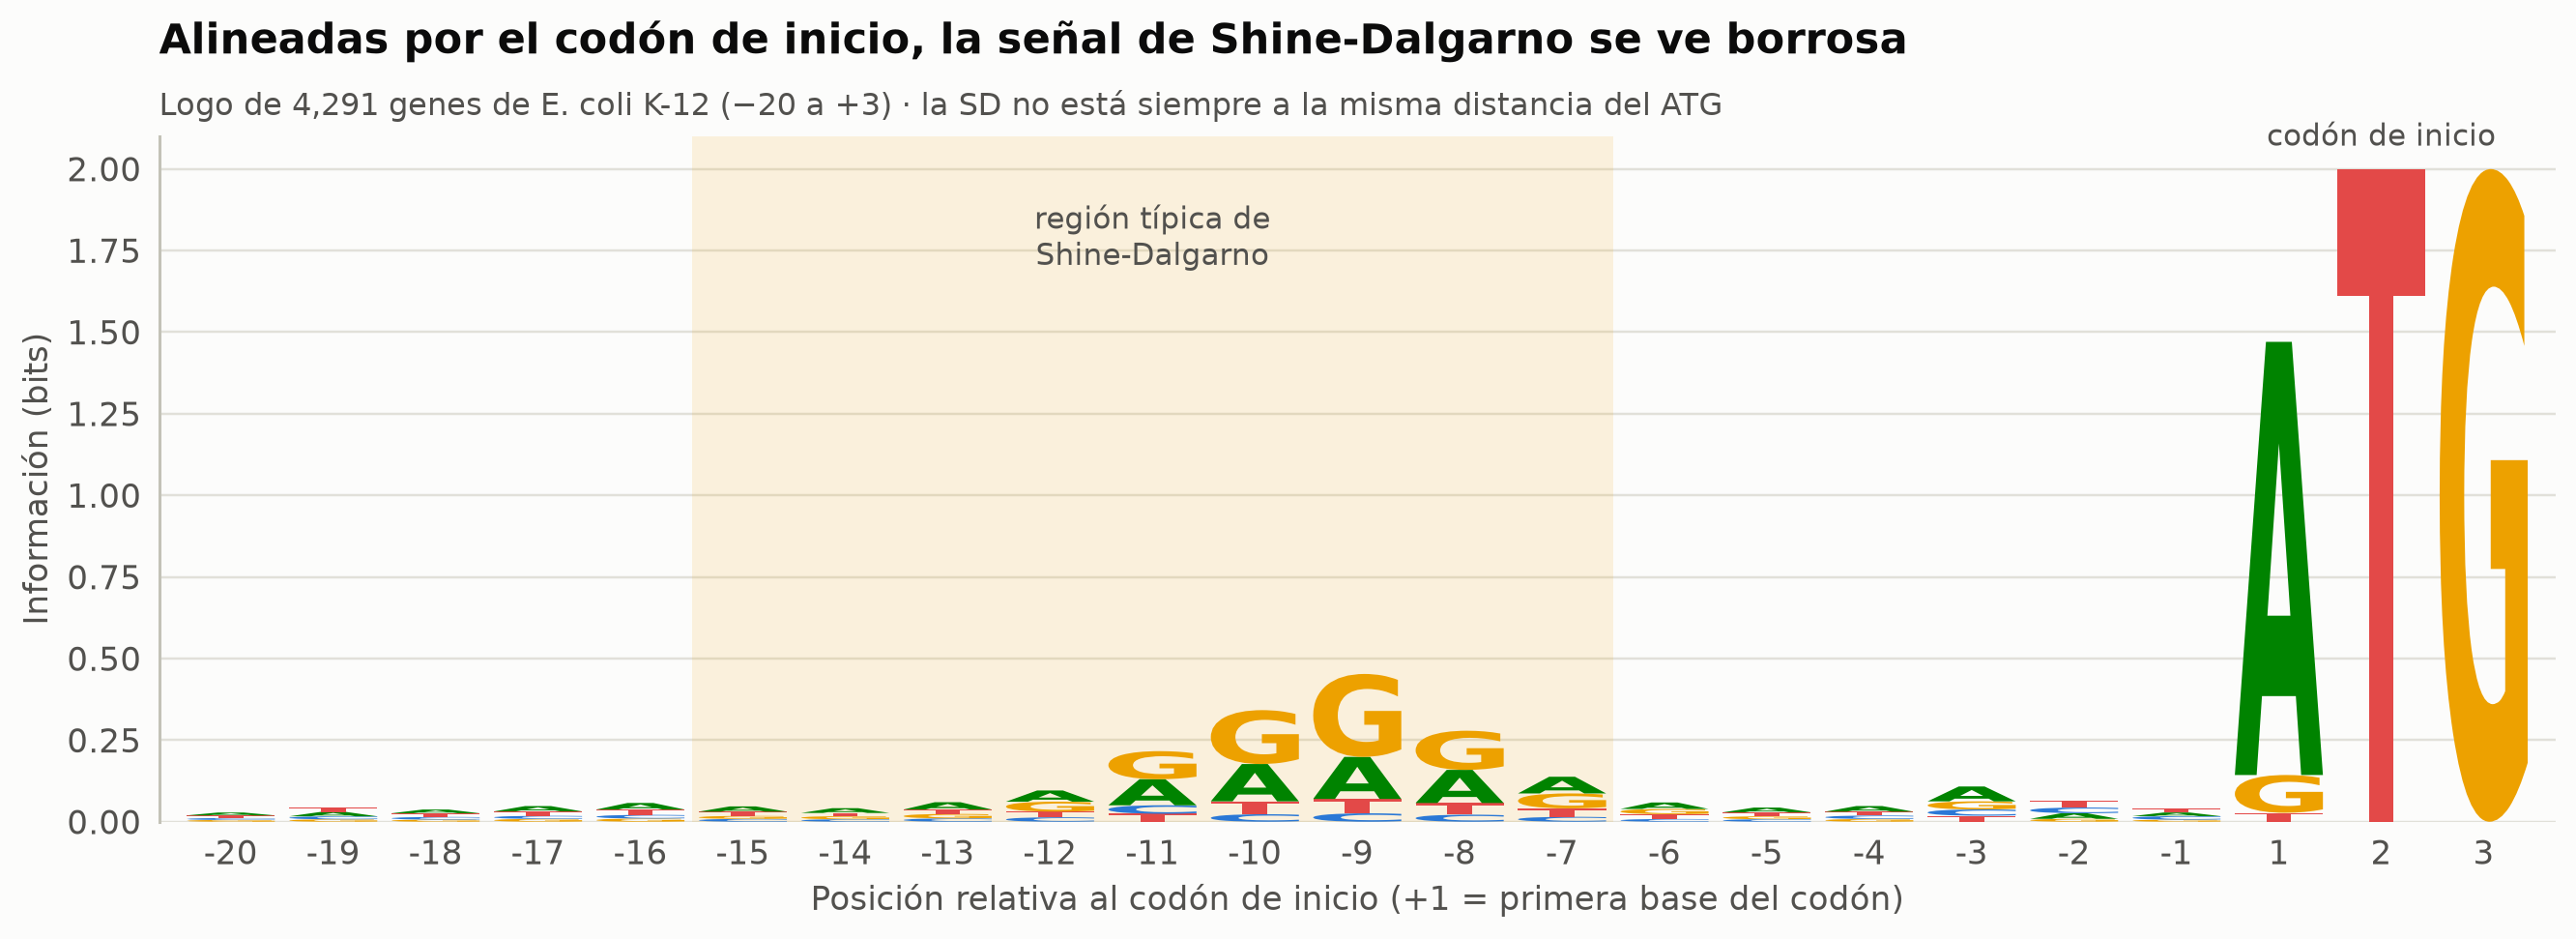

Información por columna en la región −14..−6: [0.04 0.06 0.1  0.22 0.34 0.45 0.28 0.14 0.06]


In [11]:
up_counts = count_matrix(list(ups["window"]))
up_positions = list(range(-UP, 0)) + [1, 2, 3]

fig, ax = plt.subplots(figsize=(12, 4.3))
ic_up = draw_logo(ax, up_counts, positions=up_positions, highlight=(UP - 14, UP - 6),
                  xlabel="Posición relativa al codón de inicio (+1 = primera base del codón)")
ax.text(UP - 10, 1.9, "región típica de\nShine-Dalgarno", ha="center", va="top", fontsize=10, color=ec.INK_2)
ax.text(UP + 2, ic_up[UP:].max() + 0.05, "codón de inicio", ha="center", va="bottom", fontsize=10, color=ec.INK_2)
ax.set_ylim(0, 2.1)
ec.title(ax, "Alineadas por el codón de inicio, la señal de Shine-Dalgarno se ve borrosa",
         f"Logo de {len(ups):,} genes de E. coli K-12 (−20 a +3) · la SD no está siempre a la misma distancia del ATG")
plt.show()

print("Información por columna en la región −14..−6:", np.round(ic_up[UP - 14: UP - 5], 2))

> 🔎 **Qué observamos.** Las columnas +1 a +3 son casi puras: la T y la G del codón de inicio (casi siempre `ATG`,
> a veces `GTG` o `TTG`) llegan cerca de los 2 bits. Entre −13 y −7 hay un **montículo de G y A**: la huella de
> Shine-Dalgarno. Pero es bajito (unas décimas de bit), mucho más que el ruido de las demás columnas pero lejos de lo
> que esperaríamos de una señal tan importante.
>
> ¿Por qué tan borrosa? Porque **no todos los genes ponen su SD a la misma distancia** del codón de inicio: en unos
> está a 5 nt, en otros a 9. Al alinear por el ATG, las copias de `AGGAGG` quedan desfasadas unas respecto de otras y
> sus letras se reparten entre varias columnas. Además, algunos genes (sobre todo los que están en medio de un operón
> o los *leaderless*) tienen una SD débil o carecen de ella.

Para ver el motivo con nitidez necesitamos **alinear las SD entre sí**, no los ATG. Pero no sabemos dónde está cada
una… Ese es exactamente el problema del **descubrimiento de motivos**.

## 8. El problema del descubrimiento de motivos

Hasta ahora siempre nos **dieron** los sitios alineados. En la vida real suele ocurrir lo contrario: tenemos un
conjunto de secuencias que **sospechamos** comparten un motivo (las regiones previas a genes que se activan juntos, los
fragmentos a los que se unió una proteína en un experimento ChIP-seq, las regiones previas al codón de inicio…) pero
no sabemos **ni cómo es el motivo ni dónde está** en cada secuencia.

Es un problema del huevo y la gallina:

* si supiéramos **dónde** están los sitios, construir la PWM sería trivial (secciones 2–3);
* si tuviéramos la **PWM**, encontrar el mejor sitio de cada secuencia sería trivial (sección 4).

Buscar a lo bruto es imposible: con $N$ secuencias y $P$ posiciones posibles en cada una hay $P^{N}$ combinaciones
(con 30 secuencias de 73 posiciones, $73^{30} \approx 10^{56}$). Las dos grandes estrategias clásicas resuelven el
círculo **alternando** entre los dos pasos fáciles:

| Método | Idea | Referencia |
|---|---|---|
| **Muestreador de Gibbs** | elige una secuencia, construye la PWM con **todas las demás**, y **sortea** la nueva posición de su sitio en proporción a lo bien que puntúa cada candidata | Lawrence *et al.*, 1993 |
| **EM / MEME** | en vez de elegir una posición, reparte un **peso probabilístico** entre todas y recalcula la PWM con esos pesos | Bailey y Elkan, 1994 |

Ambos suponen el modelo más sencillo: **una sola copia del motivo por secuencia** (en la jerga de MEME, *OOPS*,
*one occurrence per sequence*). Existen variantes que permiten cero o una copia (*ZOOPS*) o cualquier número.

## 9. 🎬 El muestreador de Gibbs, paso a paso

El algoritmo de Lawrence y colaboradores es sorprendentemente corto:

1. **Inicio.** Elija al azar una posición $a_n$ para el sitio de cada secuencia $n$.
2. **Saque una secuencia.** Tome la secuencia $z$ y retire su sitio del conteo.
3. **PWM sin ella.** Con los $N-1$ sitios restantes calcule $p_{b,i}$ (con pseudoconteos) y los pesos $w_{b,i}$.
4. **Puntúe todas las posiciones** $j$ de la secuencia $z$: $S_j = \sum_i w_{z_{j+i},\,i}$.
5. **Sortee** la nueva posición con probabilidad proporcional a $2^{S_j}$ (la razón de verosimilitudes, sin logaritmo):

$$
P(a_z = j) \;=\; \frac{2^{S_j}}{\sum_{k=1}^{P} 2^{S_k}}
$$

6. Devuelva el sitio al conteo y repita desde 2 con otra secuencia. Una **pasada** (*sweep*) visita las $N$ secuencias.

| Símbolo | Significado |
|---|---|
| $a_n$ | posición (inicio) del sitio en la secuencia $n$ |
| $S_j$ | puntaje log-odds de la ventana que empieza en $j$ con la PWM de las otras $N-1$ secuencias |
| $P = L - W + 1$ | número de ventanas posibles en una secuencia de longitud $L$ |

¿Por qué **sortear** y no elegir siempre la mejor? Porque al principio la PWM está hecha de sitios al azar y es casi
ruido: elegir siempre el máximo congelaría la búsqueda en el primer patrón mediocre que apareciera. El sorteo deja
explorar. Pero en cuanto unas pocas secuencias coinciden por casualidad en algo parecido al motivo real, la PWM
empieza a favorecerlo, eso atrae a más secuencias, que refuerzan la PWM… una bola de nieve que termina en el motivo.

**Un detalle práctico: el desfase.** A veces el muestreador encuentra el motivo pero "corrido" una o dos posiciones
(por ejemplo `TTACAGxx` en lugar de `GATTACAG`) y se queda atascado, porque mover **una** secuencia sola no mejora
nada. Lawrence *et al.* lo resolvieron con un paso extra: al final de cada pasada se prueba a desplazar **todos** los
sitios a la vez $-2, \dots, +2$ posiciones y se conserva el desplazamiento que más mejora el alineamiento.

La calidad de un alineamiento de sitios la medimos con su **log-verosimilitud relativa** (en bits):

$$
\mathcal{F} \;=\; \sum_{i=1}^{W}\sum_{b} n_{b,i}\,\log_2\frac{p_{b,i}}{q_b}
$$

que es simplemente la suma de los puntajes de todos los sitios con la PWM construida a partir de ellos.

In [12]:
def gibbs_sampler(X, W, n_sweeps=20, seed=0, background=None, alpha=1.0, max_shift=2, snapshot_every=None):
    """
    Muestreador de Gibbs para un motivo de longitud W (una copia por secuencia).
    X: matriz N x L de enteros 0-3 (A, C, G, T). Devuelve posiciones, conteos, historial y F por pasada.
    """
    rng = np.random.default_rng(seed)
    N, L = X.shape
    P = L - W + 1
    q = np.bincount(X.ravel(), minlength=4) / X.size if background is None else np.asarray(background)
    windows = X[:, np.arange(P)[:, None] + np.arange(W)]      # N x P x W: todas las ventanas de cada secuencia
    cols = np.arange(W)
    log_q = np.log2(q)[:, None]

    def counts_of(positions):
        c = np.zeros((4, W))
        np.add.at(c, (windows[np.arange(N), positions], cols), 1)
        return c

    def fitness(c):
        return float((c * (np.log2((c + alpha * q[:, None]) / (N + alpha)) - log_q)).sum())

    pos = rng.integers(0, P, N)                               # 1. inicio al azar
    counts = counts_of(pos)
    history, F = [(counts.copy(), pos.copy())], []
    step = 0
    for sweep in range(n_sweeps):
        for n in rng.permutation(N):
            counts[windows[n, pos[n]], cols] -= 1              # 2. saca el sitio de la secuencia n
            pwm = np.log2((counts + alpha * q[:, None]) / (N - 1 + alpha)) - log_q   # 3. PWM sin ella
            s = pwm[windows[n], cols].sum(axis=1)              # 4. puntaje de cada ventana
            weights = np.exp2(s - s.max())                     # 5. sorteo proporcional a 2^S
            cum = np.cumsum(weights)
            pos[n] = np.searchsorted(cum, rng.random() * cum[-1])
            counts[windows[n, pos[n]], cols] += 1              # 6. devuelve el sitio
            step += 1
            if snapshot_every and step % snapshot_every == 0:
                history.append((counts.copy(), pos.copy()))
        # Paso de desfase: probar a correr todos los sitios a la vez
        best = (fitness(counts), pos, counts)
        for d in range(-max_shift, max_shift + 1):
            new = pos + d
            if d == 0 or new.min() < 0 or new.max() > P - 1:
                continue
            c = counts_of(new)
            if fitness(c) > best[0]:
                best = (fitness(c), new, c)
        F.append(best[0]); pos, counts = best[1].copy(), best[2].copy()
        if snapshot_every:
            history.append((counts.copy(), pos.copy()))
    return pos, counts, history, F

def encode(seqs):
    """Lista de secuencias de igual longitud → matriz de enteros 0-3."""
    return np.array([[B_INDEX[b] for b in s] for s in seqs])

print("Muestreador de Gibbs definido.")

Muestreador de Gibbs definido.


### Un banco de pruebas donde conocemos la respuesta

Antes de confiar en el algoritmo con datos reales lo probamos donde **sabemos la verdad**: generamos 30 secuencias
aleatorias de 80 nt y en cada una **implantamos** una copia del motivo `GATTACAG` en una posición al azar, con un 20 %
de probabilidad de mutar cada base. Una copia típica difiere del consenso en una o dos letras; a simple vista es
imposible encontrarlas.

In [13]:
MOTIF, N_SYN, L_SYN, W_SYN, MUT = "GATTACAG", 30, 80, 8, 0.20
syn_rng = np.random.default_rng(7)
X_syn = syn_rng.integers(0, 4, (N_SYN, L_SYN))
true_pos = syn_rng.integers(0, L_SYN - W_SYN + 1, N_SYN)
for n in range(N_SYN):
    for i, b in enumerate(MOTIF):
        X_syn[n, true_pos[n] + i] = B_INDEX[b] if syn_rng.random() > MUT else syn_rng.integers(0, 4)
syn_seqs = ["".join(BASES[k] for k in row) for row in X_syn]
implanted = [s[p:p + W_SYN] for s, p in zip(syn_seqs, true_pos)]
for s, p in list(zip(syn_seqs, true_pos))[:5]:
    print(s[:p].lower() + s[p:p + W_SYN] + s[p + W_SYN:].lower())
print("…\nCopias implantadas (primeras 10):", implanted[:10])
print("Copias idénticas al consenso:", sum(m == MOTIF for m in implanted), "de", N_SYN)

tggtgttaaccttactatactcccgctccggggtttggctcatatgaacaagtGATTCGAGccataaatgtagccagtga
gcttagGATTACAGaggggtgcggaagcgcaactccgtcgcgcgggtagccaactacttaagacctaggattctgttgca
gattagaactATTTACTGaagattgctgccctaagctatactaggcagctgcagcgtctggttttactcagtgtgatctt
tatgcttgagaaaatcaacccttgtcacatacatagtgtttgggtcttccgCATTAGAAtgcttggcgagttccgcgaaa
caGTTTACAGtcagcgccattcagcgaagagcatgttgtattgtgttgttcaaacaccgatatgaacgaaagaaccgttg
…
Copias implantadas (primeras 10): ['GATTCGAG', 'GATTACAG', 'ATTTACTG', 'CATTAGAA', 'GTTTACAG', 'GCTGACAG', 'GATTACAG', 'GACTACAG', 'GATTACAA', 'GATTACAG']
Copias idénticas al consenso: 10 de 30


![El muestreador de Gibbs parte de sitios al azar y en pocas pasadas el logo converge al motivo implantado](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-04-msa-motivos-hmm/4.2_gibbs_logo.gif)

*El muestreador de Gibbs parte de sitios al azar y en pocas pasadas el logo converge al motivo implantado*

In [14]:
t0 = time.perf_counter()
pos_syn, counts_syn, hist_syn, F_syn = gibbs_sampler(X_syn, W_SYN, n_sweeps=10, seed=1,
                                                     background=np.full(4, 0.25), snapshot_every=6)
print(f"{len(hist_syn)} instantáneas en {time.perf_counter() - t0:.2f} s · consenso final:",
      "".join(BASES[k] for k in counts_syn.argmax(0)), f"· aciertos exactos: {(pos_syn == true_pos).mean():.0%}")

frames = hist_syn[:60]
fig, (ax_logo, ax_seq) = plt.subplots(2, 1, figsize=(10, 7.4), height_ratios=[1, 1.5])

def update(f):
    ax_logo.clear(); ax_seq.clear()
    c, p = frames[f]
    ic = draw_logo(ax_logo, c, correct=True)
    cons = "".join(BASES[k] for k in c.argmax(0))
    ax_logo.set_title(f"Logo de los sitios elegidos · consenso actual: {cons} · {ic.sum():.1f} bits", fontsize=12)
    hits = p == true_pos
    for n in range(N_SYN):
        ax_seq.plot([0, L_SYN], [n, n], color=ec.GRID, lw=1, solid_capstyle="butt")
        ax_seq.add_patch(Rectangle((true_pos[n], n - 0.42), W_SYN, 0.84, fill=False, ec=ec.INK_2, lw=1))
        ax_seq.add_patch(Rectangle((p[n], n - 0.3), W_SYN, 0.6, color=ec.BLUE if hits[n] else ec.ORANGE, lw=0))
    ax_seq.set_xlim(0, L_SYN); ax_seq.set_ylim(N_SYN - 0.4, -0.6)
    ax_seq.set_yticks([]); ax_seq.grid(False); ax_seq.spines["left"].set_visible(False)
    ax_seq.set_xlabel("Posición en la secuencia (nt)")
    ax_seq.set_title(f"Sitio elegido en cada secuencia · azul: coincide con el implantado (marco gris) · "
                     f"{hits.sum()}/{N_SYN}", fontsize=11, loc="left")
    return ()

ec.animate(fig, update, frames=len(frames), interval=260, name="4.2_gibbs_logo")

61 instantáneas en 0.01 s · consenso final: GATTACAG · aciertos exactos: 87%


▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Al principio los sitios elegidos (barras naranjas) están dispersos y el logo es casi plano:
> ninguna columna supera unas décimas de bit. Tras unas pocas pasadas aparece una "semilla" de acuerdo; en ese
> momento la PWM empieza a atraer a las demás secuencias y el logo **crece de golpe** hasta `GATTACAG`. Al final unas
> pocas secuencias siguen sin coincidir: son copias implantadas tan mutadas que otra ventana de la secuencia se
> parece más al motivo. Eso no es un error del algoritmo, es un límite de la información disponible.

El muestreador es **estocástico**: cada semilla aleatoria sigue un camino distinto. Ejecutémoslo con 8 semillas y
sigamos $\mathcal{F}$ pasada a pasada.

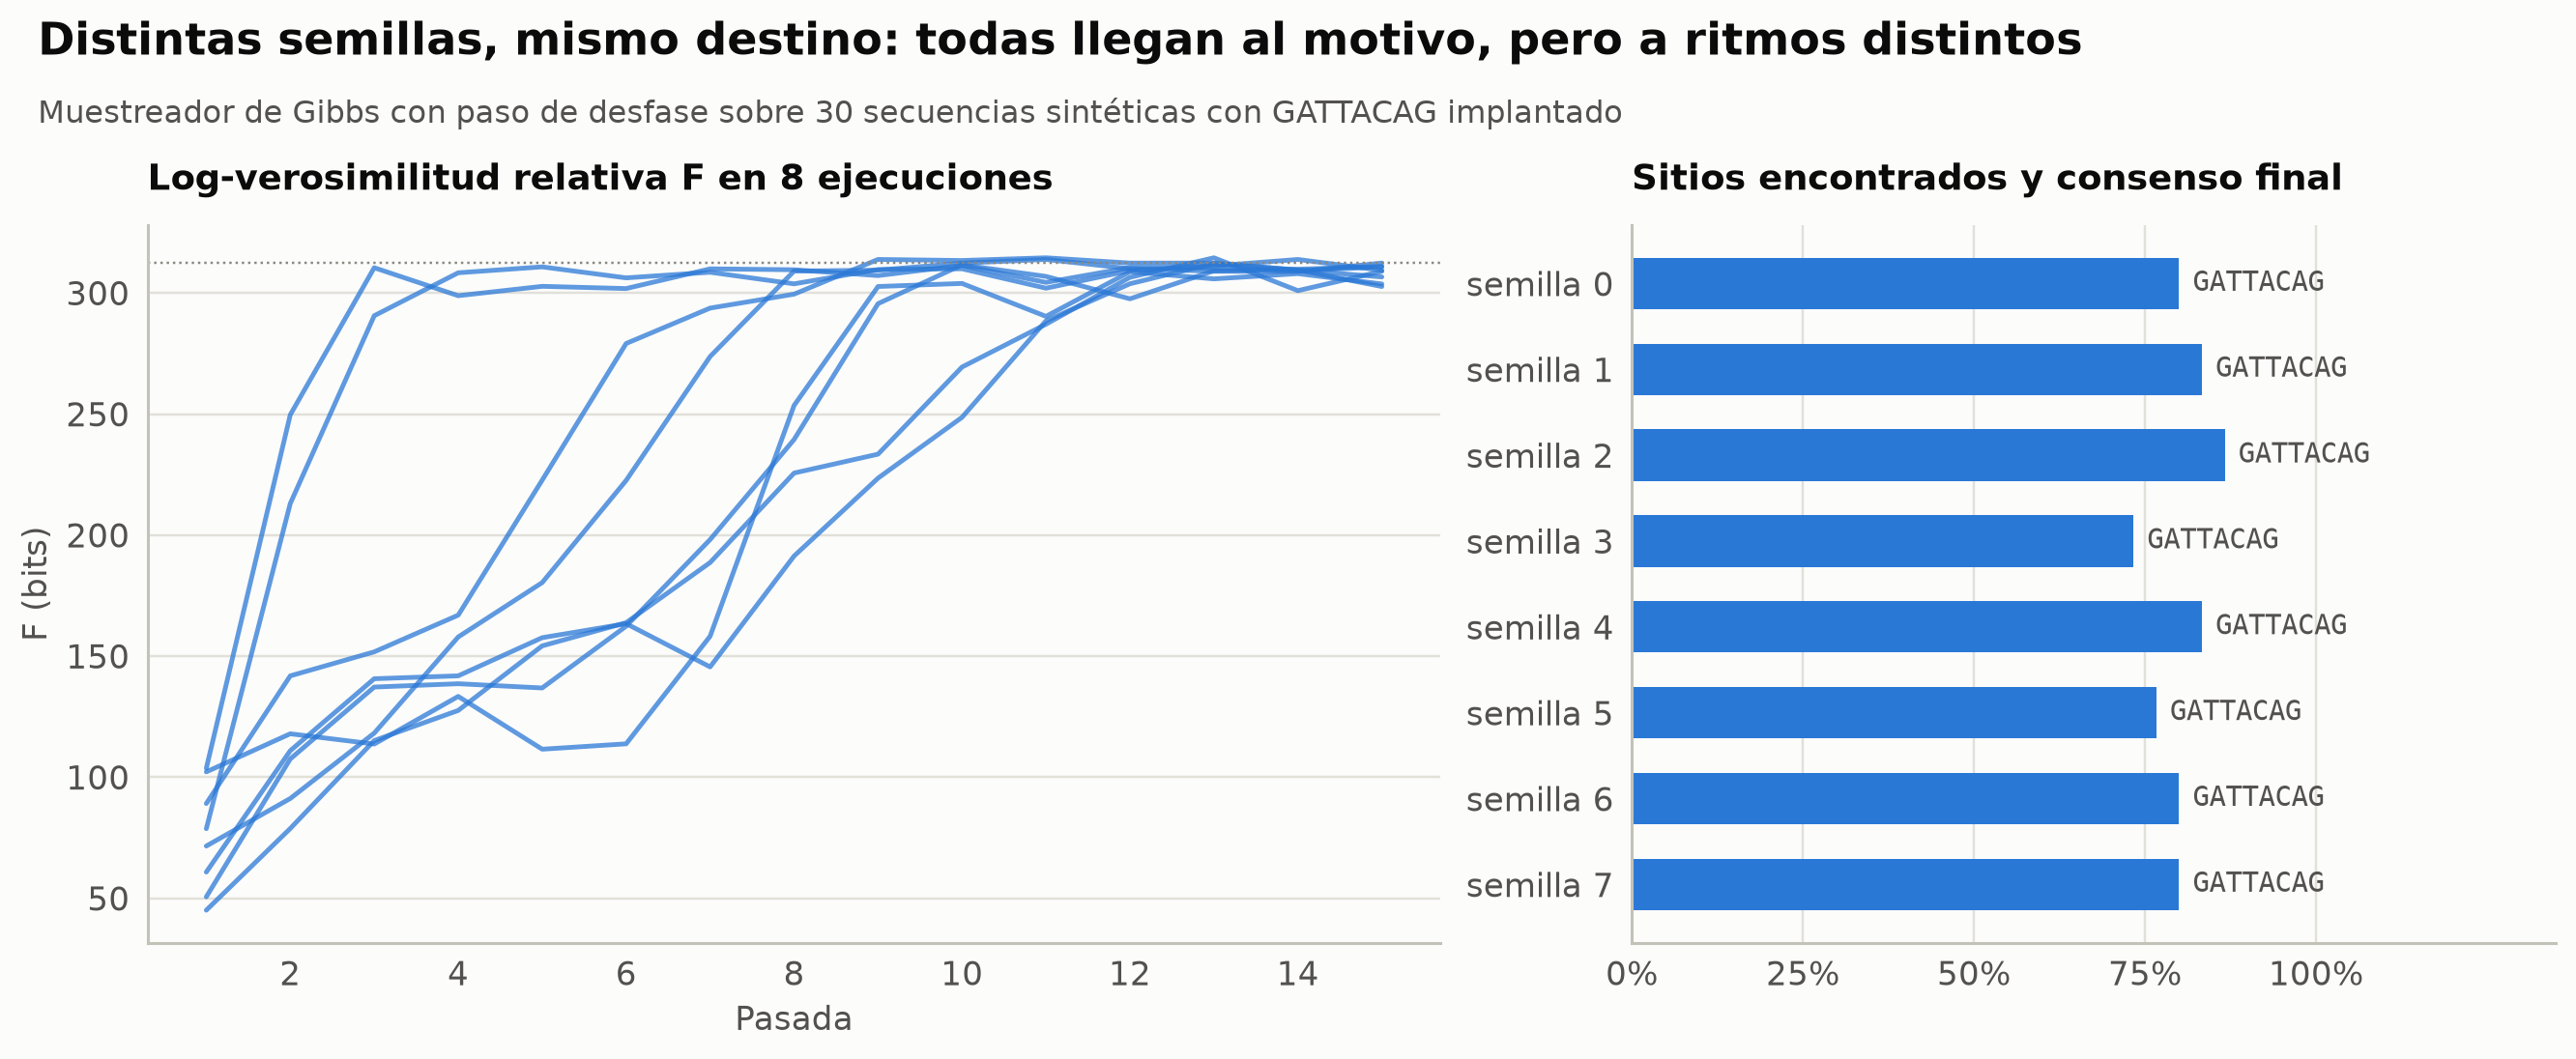

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), width_ratios=[1.4, 1])
runs = []
for seed in range(8):
    p, c, _, F = gibbs_sampler(X_syn, W_SYN, n_sweeps=15, seed=seed, background=np.full(4, 0.25))
    runs.append((seed, F, (p == true_pos).mean(), "".join(BASES[k] for k in c.argmax(0))))
    axes[0].plot(range(1, 16), F, "-", color=ec.BLUE, alpha=0.75, lw=1.6)
axes[0].axhline(max(r[1][-1] for r in runs), color=ec.MUTED, lw=0.8, ls=":")
axes[0].set_xlabel("Pasada"); axes[0].set_ylabel("F (bits)")
axes[0].set_title("Log-verosimilitud relativa F en 8 ejecuciones", fontsize=12)
res = pd.DataFrame(runs, columns=["semilla", "F", "aciertos", "consenso"])
axes[1].barh([f"semilla {s}" for s in res["semilla"]], res["aciertos"], color=ec.BLUE, height=0.6)
for k, r in res.iterrows():
    axes[1].text(r["aciertos"] + 0.02, k, r["consenso"], va="center", fontsize=9.5, family="DejaVu Sans Mono",
                 color=ec.INK_2)
axes[1].set_xlim(0, 1.35); axes[1].set_xticks([0, 0.25, 0.5, 0.75, 1.0]); axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[1].grid(axis="y", visible=False); axes[1].grid(axis="x", visible=True)
axes[1].set_title("Sitios encontrados y consenso final", fontsize=12)
ec.fig_title(fig, "Distintas semillas, mismo destino: todas llegan al motivo, pero a ritmos distintos",
             "Muestreador de Gibbs con paso de desfase sobre 30 secuencias sintéticas con GATTACAG implantado")
plt.show()

> 🔎 **Qué observamos.** Algunas ejecuciones "encuentran la semilla" en la segunda o tercera pasada y otras tardan ocho o diez;
> durante ese tiempo $\mathcal{F}$ se queda en una meseta baja. Una vez que despega, sube hasta el mismo techo. Por eso
> en la práctica se lanzan **varias ejecuciones** y se conserva la de mayor $\mathcal{F}$. Sin el paso de desfase,
> varias de estas ejecuciones se habrían quedado con versiones corridas del motivo (`TTACAGxx`, `xxGATTAC`).

> ✅ **Compruebe su comprensión.** ¿Qué pasaría si le pidiéramos al muestreador un motivo de longitud $W = 6$ en estos
> mismos datos? ¿Y de $W = 12$? *(Pista: con 6 encontraría una parte de `GATTACAG`; con 12, el motivo más cuatro
> columnas de ruido casi sin información.)*

## 10. 🧪 Redescubrir Shine-Dalgarno en *E. coli*

Ahora sí: le damos al muestreador las regiones de −20 a −1 de los genes de *E. coli* **sin decirle nada** sobre
`AGGAGG`, y le pedimos un motivo de $W = 6$.

Tres decisiones de diseño, explicadas:

* **Entrenamiento y prueba.** Usamos 1 500 genes elegidos al azar para *descubrir* el motivo y guardamos los
  ~2 800 restantes para *evaluarlo* después (sección 12). Si evaluáramos la PWM en las mismas secuencias con que la
  construimos, sería como corregir un examen con las respuestas a la vista.
* **El fondo $q_b$ durante el descubrimiento.** La región previa a los genes es más rica en A y T que el genoma. Si
  usáramos la composición del genoma como fondo, el muestreador "descubriría" que estas regiones tienen muchas A y T,
  algo cierto pero aburrido. Por eso usamos como fondo **la composición de las propias ventanas**: así sólo destaca lo
  que es especial **dentro** de ellas.
* **Varias ejecuciones.** Lanzamos 3 semillas y nos quedamos con la de mayor $\mathcal{F}$.

> 🤔 **Antes de ejecutar, prediga.** El muestreador no sabe biología. ¿Encontrará algo parecido a `AGGAGG`, o algún
> otro patrón (por ejemplo, repeticiones de A y T)?

In [16]:
X_up = encode(list(ups["window"].str[:UP]))              # sólo −20..−1: no le mostramos el codón de inicio
q_up = np.bincount(X_up.ravel(), minlength=4) / X_up.size
print("Composición de las ventanas (A, C, G, T):", np.round(q_up, 3))

split_rng = np.random.default_rng(2024)
train_idx = np.sort(split_rng.choice(len(ups), 1500, replace=False))
test_mask = np.ones(len(ups), bool); test_mask[train_idx] = False

W_SD = 6
t0 = time.perf_counter()
best = None
for seed in range(3):
    p, c, _, F = gibbs_sampler(X_up[train_idx], W_SD, n_sweeps=12, seed=seed, background=q_up)
    cons = "".join(BASES[k] for k in c.argmax(0))
    print(f"semilla {seed}: consenso {cons}   F = {F[-1]:.0f} bits")
    if best is None or F[-1] > best[2]:
        best = (p, c, F[-1])
sd_pos, sd_counts, _ = best
SD_CONSENSUS = "".join(BASES[k] for k in sd_counts.argmax(0))
sd_sites = ["".join(BASES[k] for k in X_up[train_idx][n, p:p + W_SD]) for n, p in enumerate(sd_pos)]
print(f"\nMotivo descubierto: {SD_CONSENSUS}   ({time.perf_counter() - t0:.1f} s)")
print("Sitios más frecuentes:", Counter(sd_sites).most_common(8))

Composición de las ventanas (A, C, G, T): [0.337 0.17  0.261 0.232]
semilla 0: consenso AAGGAG   F = 5074 bits


semilla 1: consenso AAGGAG   F = 4830 bits
semilla 2: consenso AAGGAG   F = 4891 bits

Motivo descubierto: AAGGAG   (0.5 s)
Sitios más frecuentes: [('AAGGAG', 103), ('CAGGAG', 94), ('AAGGAA', 57), ('GAGGAA', 42), ('AAGGAT', 41), ('CTGGAG', 37), ('CAGGAA', 36), ('ATGGAG', 24)]


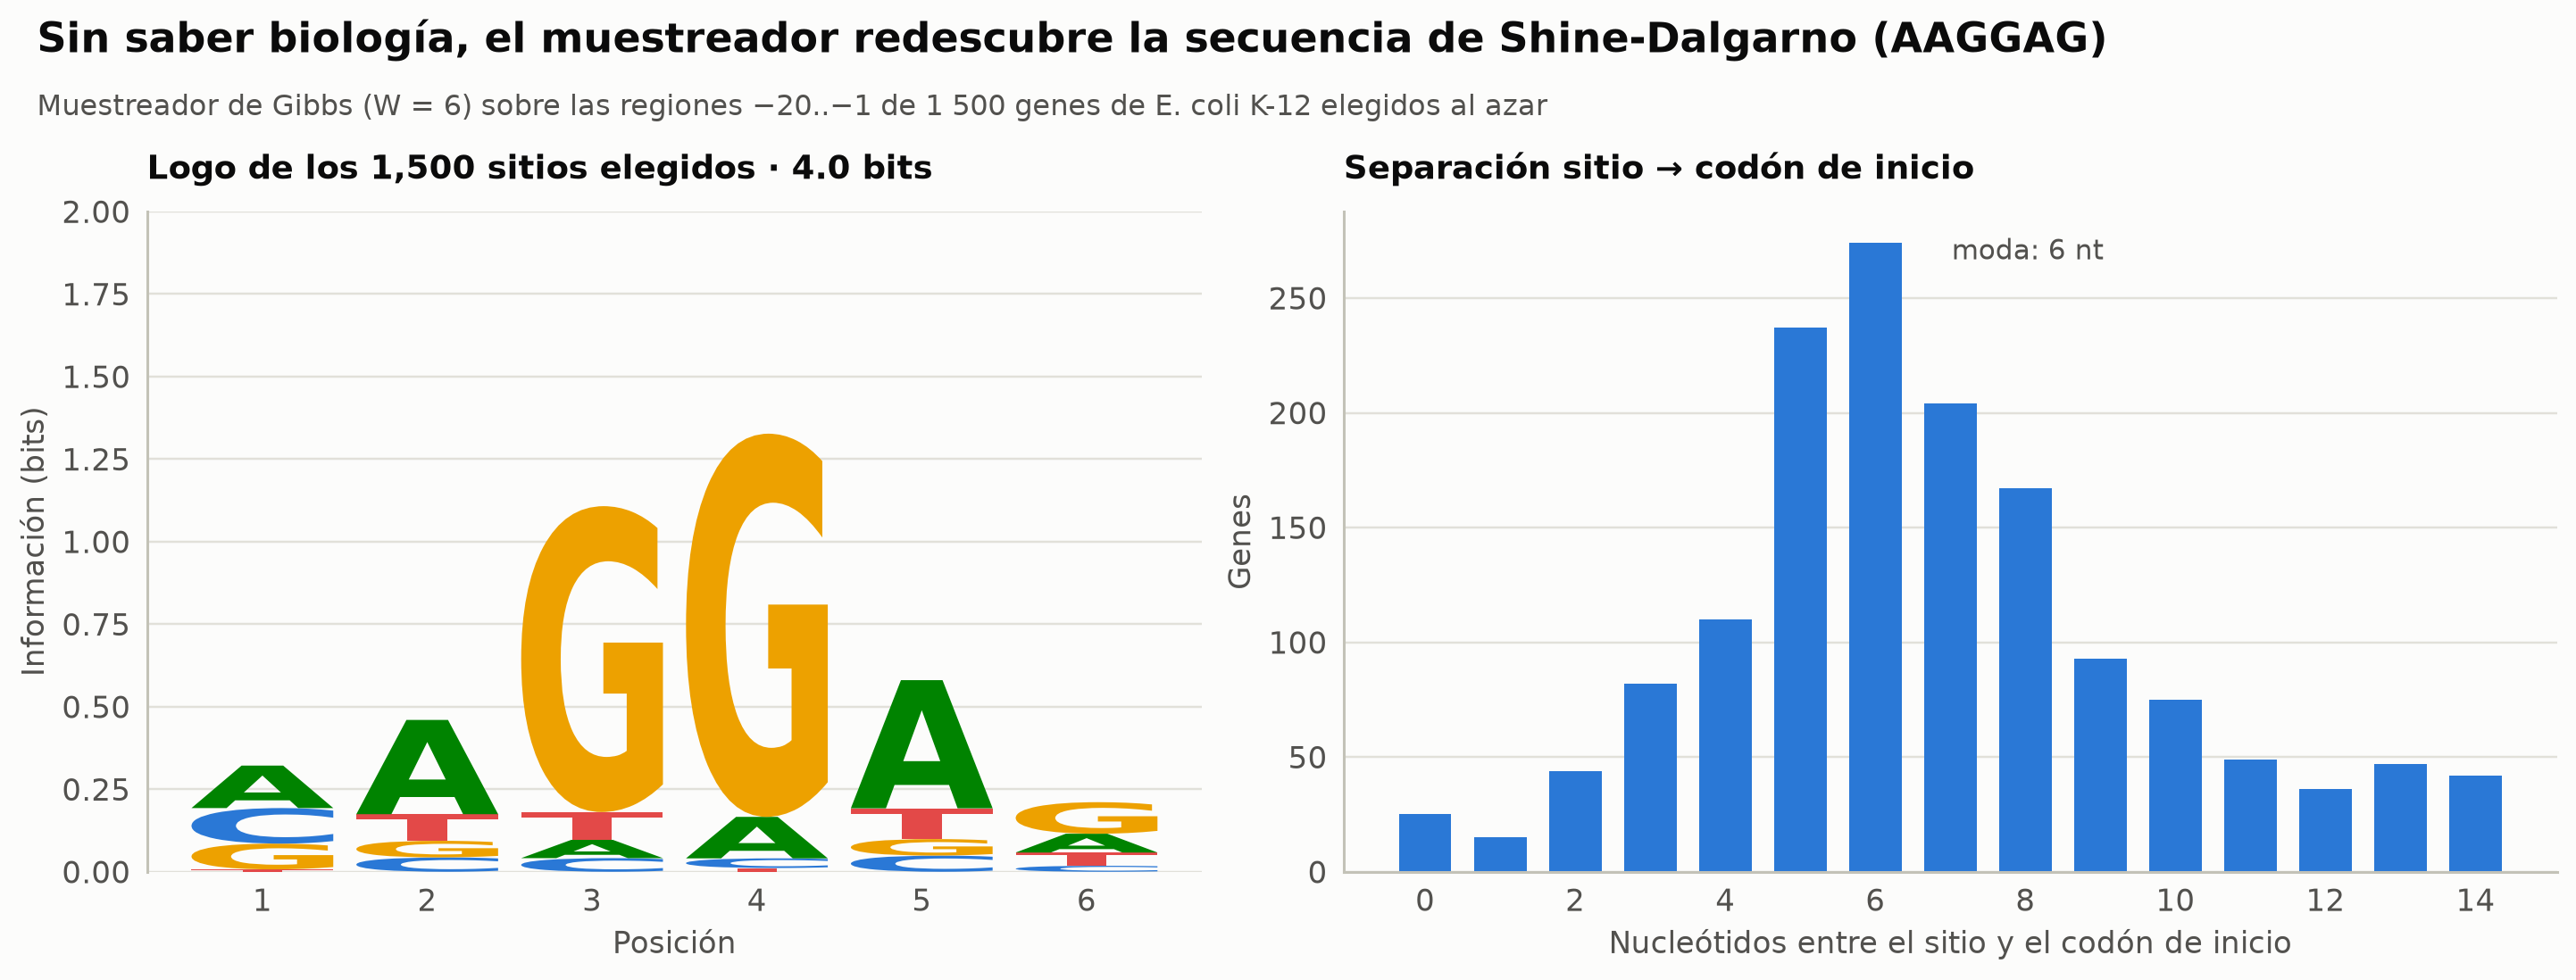

In [17]:
# Distancia entre el final del sitio y el codón de inicio (nt que quedan entre ambos)
spacing = UP - (sd_pos + W_SD)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), width_ratios=[1, 1.15])
ic_sd = draw_logo(axes[0], sd_counts, correct=True)
axes[0].set_title(f"Logo de los {len(sd_pos):,} sitios elegidos · {ic_sd.sum():.1f} bits", fontsize=12)
vals, cnts = np.unique(spacing, return_counts=True)
axes[1].bar(vals, cnts, color=ec.BLUE, width=0.7)
mode = vals[np.argmax(cnts)]
axes[1].annotate(f"moda: {mode} nt", (mode, cnts.max()), xytext=(28, -6), textcoords="offset points",
                 fontsize=10, color=ec.INK_2, arrowprops=dict(arrowstyle="-", color=ec.MUTED))
axes[1].set_xlabel("Nucleótidos entre el sitio y el codón de inicio")
axes[1].set_ylabel("Genes"); axes[1].grid(axis="x", visible=False)
axes[1].set_xticks(range(0, UP - W_SD + 1, 2))
axes[1].set_title("Separación sitio → codón de inicio", fontsize=12)
ec.fig_title(fig, f"Sin saber biología, el muestreador redescubre la secuencia de Shine-Dalgarno ({SD_CONSENSUS})",
             "Muestreador de Gibbs (W = 6) sobre las regiones −20..−1 de 1 500 genes de E. coli K-12 elegidos al azar")
plt.show()

> 🔎 **Qué observamos.** El logo es ahora mucho más nítido que el de la sección 7: las G y A de Shine-Dalgarno, que
> antes se repartían entre varias columnas, se apilan en su sitio. La separación hasta el codón de inicio **no es
> fija**: se concentra entre unos 4 y 9 nucleótidos, justo la variabilidad que borraba el logo alineado por el ATG.
> La cola de separaciones extremas (0–2 o más de 11) corresponde en buena parte a genes **sin** una SD clara, a los
> que el modelo OOPS obliga a asignarles "algún" sitio: la limitación del supuesto de una copia por secuencia.

### La prueba de fuego: ¿se aparea con el ARN ribosomal 16S?

La hipótesis de Shine y Dalgarno era física: el motivo existe porque es **complementario** al extremo 3′ del ARN 16S.
Podemos verificarlo sin salir de nuestros archivos: la anotación incluye los siete genes de ARN ribosomal 16S
(*rrsA* … *rrsH*), así que extraemos su extremo 3′ del genoma y buscamos cómo aparea con el consenso descubierto.

7 genes 16S · extremos 3′ distintos: {'GGATCACCTCCTTA'}


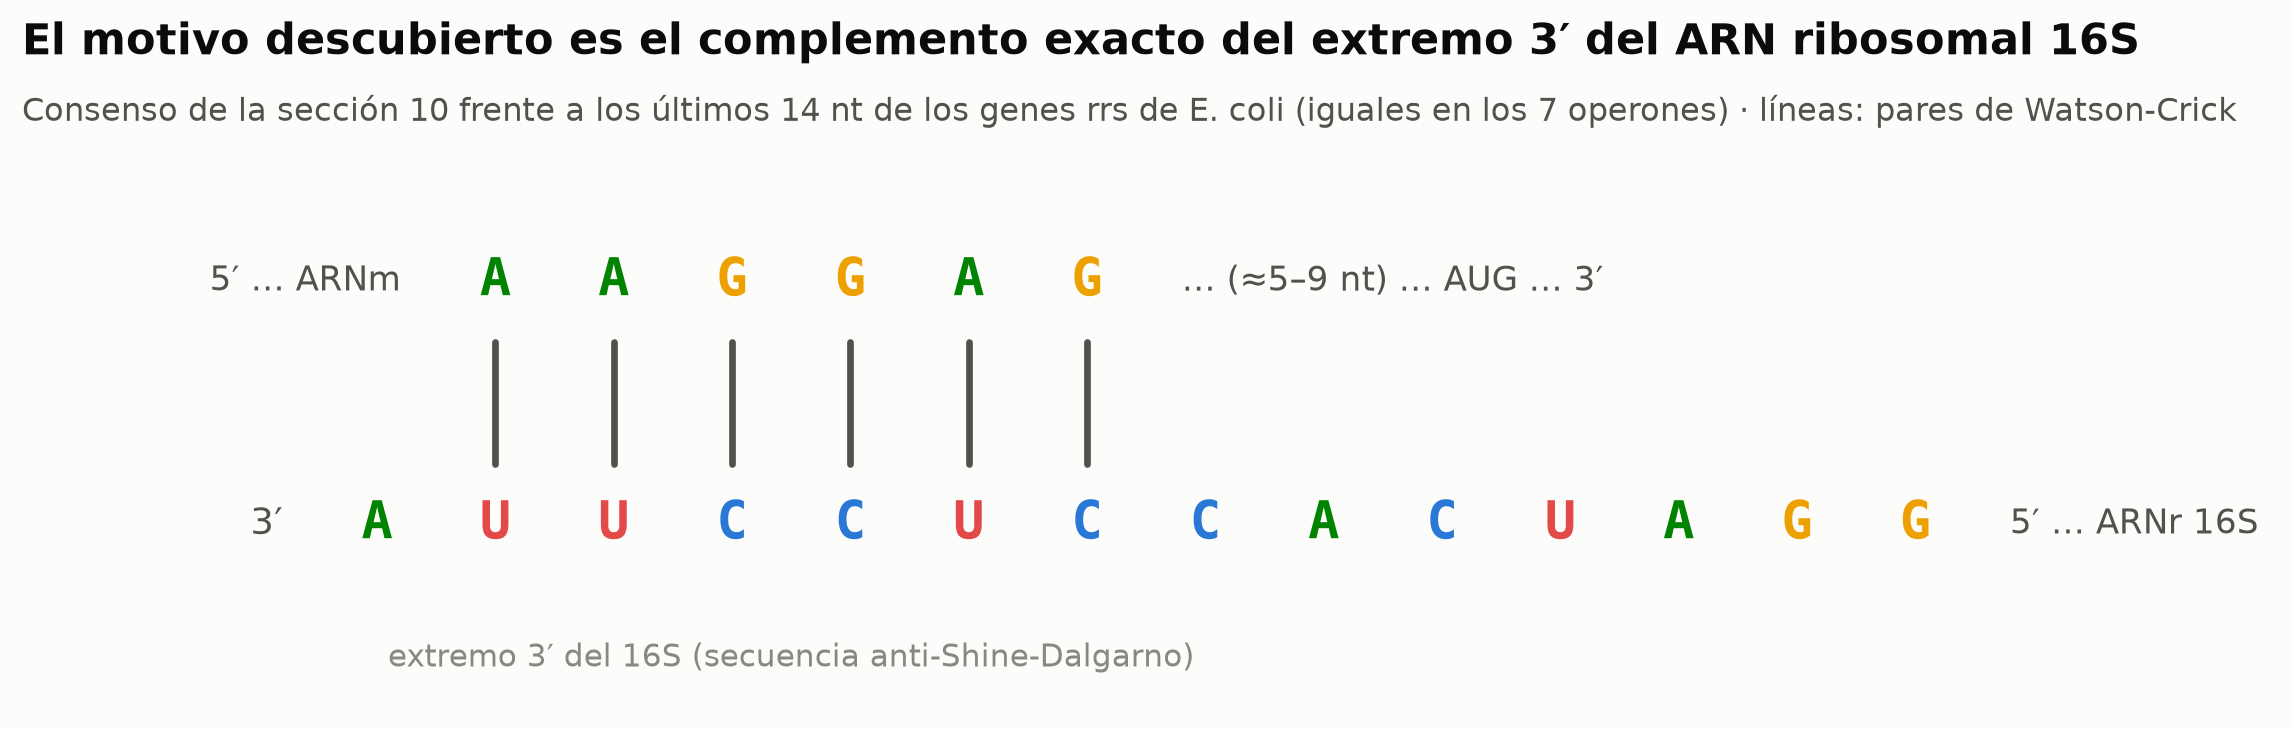

In [18]:
rrs = annot[(annot["type"] == "rRNA") & annot["product"].str.contains("16S")]
tails = set()
for r in rrs.itertuples():
    s = genome[r.start - 1: r.end] if r.strand == "+" else revcomp(genome[r.start - 1: r.end])
    tails.add(s[-14:])
print(f"{len(rrs)} genes 16S · extremos 3′ distintos: {tails}")
tail = tails.pop()                              # los siete operones rrn comparten este extremo

# Buscar el desplazamiento que maximiza los pares Watson-Crick entre el consenso y el 16S leído 3'→5'
anti = tail[::-1]                               # 16S escrito de 3' a 5'
pairs_ok = {("A", "T"), ("T", "A"), ("G", "C"), ("C", "G")}
wobble = {("G", "T"), ("T", "G")}
best_off = max(range(len(anti) - W_SD + 1),
               key=lambda o: sum((a, b) in pairs_ok for a, b in zip(SD_CONSENSUS, anti[o:o + W_SD])))

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.axis("off"); ax.set_xlim(-3, len(anti) + 2); ax.set_ylim(-0.9, 1.9)
to_rna = lambda s: s.replace("T", "U")
mrna = "·" * best_off + SD_CONSENSUS
for k, b in enumerate(to_rna(anti)):
    ax.text(k, 0, b, ha="center", va="center", fontsize=17, fontweight="bold", family="DejaVu Sans Mono",
            color=ec.NUC_COLORS.get(b, ec.INK))
for k, b in enumerate(SD_CONSENSUS):
    x = best_off + k
    ax.text(x, 1.2, to_rna(b), ha="center", va="center", fontsize=17, fontweight="bold",
            family="DejaVu Sans Mono", color=ec.NUC_COLORS[b])
    pair = (b, anti[x])
    if pair in pairs_ok:
        ax.plot([x, x], [0.3, 0.9], color=ec.INK_2, lw=2.2)
    elif pair in wobble:
        ax.plot([x, x], [0.3, 0.9], color=ec.MUTED, lw=1.5, ls=":")
ax.text(best_off - 0.8, 1.2, "5′ … ARNm", ha="right", va="center", fontsize=11, color=ec.INK_2)
ax.text(best_off + W_SD - 0.2, 1.2, "… (≈5–9 nt) … AUG … 3′", ha="left", va="center", fontsize=11, color=ec.INK_2)
ax.text(-0.8, 0, "3′", ha="right", va="center", fontsize=12, color=ec.INK_2)
ax.text(len(anti) - 0.2, 0, "5′ … ARNr 16S", ha="left", va="center", fontsize=11, color=ec.INK_2)
ax.text(best_off + W_SD / 2 - 0.5, -0.7, "extremo 3′ del 16S (secuencia anti-Shine-Dalgarno)", ha="center",
        fontsize=10, color=ec.MUTED)
ec.title(ax, "El motivo descubierto es el complemento exacto del extremo 3′ del ARN ribosomal 16S",
         f"Consenso de la sección 10 frente a los últimos 14 nt de los genes rrs de E. coli (iguales en los {len(rrs)} operones) · líneas: pares de Watson-Crick")
plt.show()

> 🔎 **Qué observamos.** Las seis bases del consenso descubierto forman pares de Watson-Crick con el extremo del ARN 16S
> (en el ARN, G·U también puede aparear débilmente). Un algoritmo puramente estadístico, alimentado sólo con
> secuencias, recuperó la misma explicación física que Shine y Dalgarno propusieron en 1974. Este es el tipo de
> comprobación independiente que convierte un patrón estadístico en una afirmación biológica creíble.

### La PWM de Shine-Dalgarno, explorable

Con los 1 500 sitios construimos la PWM definitiva. Para **escanear el genoma** (secciones 11–13) usamos ahora como
fondo la composición del **genoma completo**, porque es contra ese fondo que vamos a buscar. Pase el cursor sobre las
celdas: verá el conteo, la frecuencia, el peso log-odds y cuántos bits aporta cada letra al logo.

Composición del genoma (A, C, G, T): [0.246 0.254 0.254 0.246]


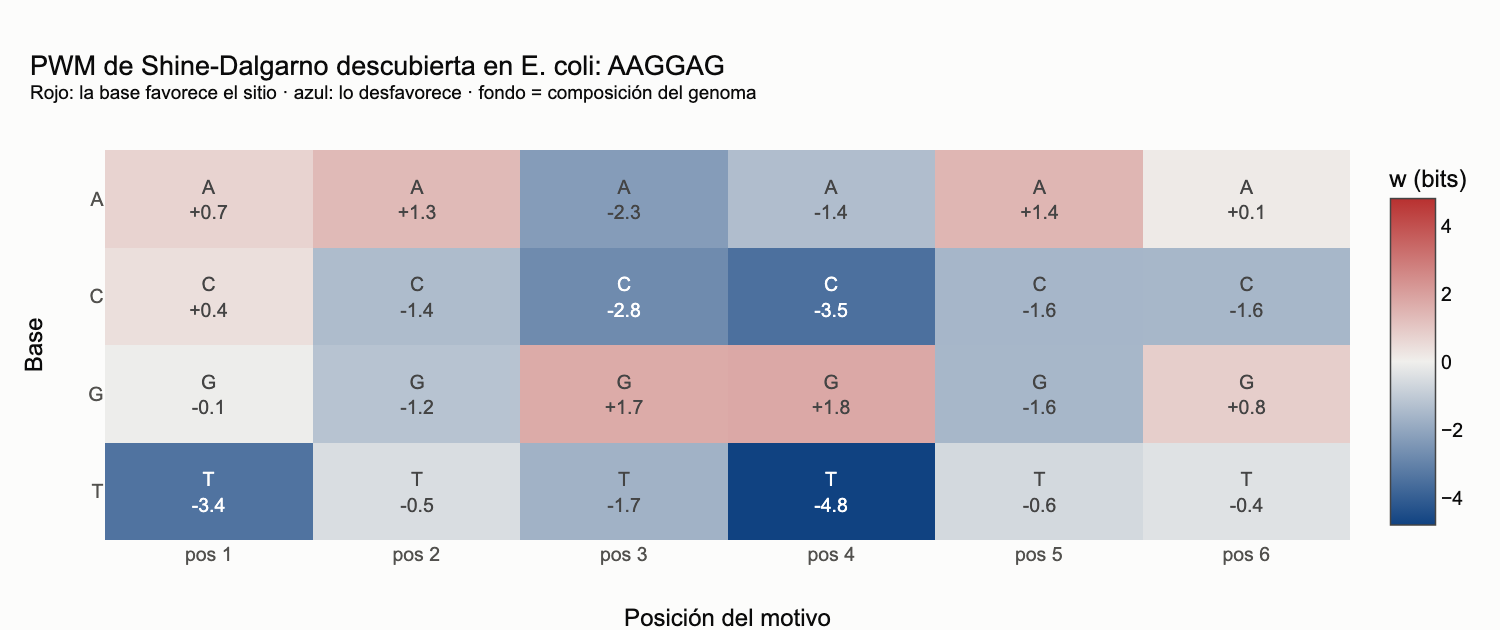

Puntaje máximo posible: 7.82 bits · mínimo: -15.56 bits


In [19]:
g_idx = np.frombuffer(genome.encode("ascii"), dtype=np.uint8)
LOOKUP = np.full(256, 4, dtype=np.int8)
for b, k in B_INDEX.items():
    LOOKUP[ord(b)] = k
g_int = LOOKUP[g_idx]
q_genome = np.bincount(g_int[g_int < 4], minlength=4) / np.sum(g_int < 4)
print("Composición del genoma (A, C, G, T):", np.round(q_genome, 3))

sd_freq = frequencies(sd_counts, background=q_genome, alpha=1.0)
sd_pwm = pwm_log_odds(sd_freq, background=q_genome)
sd_bits = (sd_counts / sd_counts.sum(0)) * information_content(sd_counts)

custom = np.dstack([sd_counts, sd_freq, sd_pwm, sd_bits])
fig = go.Figure(go.Heatmap(
    z=sd_pwm, x=[f"pos {i + 1}" for i in range(W_SD)], y=list(BASES), customdata=custom,
    colorscale=[[0, "#104281"], [0.5, "#f0efec"], [1, "#b8302f"]], zmid=0,
    text=[[f"{b}<br>{v:+.1f}" for v in row] for b, row in zip(BASES, sd_pwm)], texttemplate="%{text}",
    hovertemplate=("<b>base %{y} · %{x}</b><br>conteo: %{customdata[0]:.0f}<br>frecuencia: %{customdata[1]:.3f}"
                   "<br>peso w = log₂(p/q): %{customdata[2]:+.2f} bits<br>altura en el logo: %{customdata[3]:.2f} bits"
                   "<extra></extra>"),
    colorbar=dict(title="w (bits)")))
fig.update_layout(
    title=dict(text=f"PWM de Shine-Dalgarno descubierta en E. coli: {SD_CONSENSUS}"
                    "<br><sup>Rojo: la base favorece el sitio · azul: lo desfavorece · fondo = composición del genoma</sup>"),
    yaxis=dict(autorange="reversed", title="Base"), xaxis_title="Posición del motivo",
    height=420, margin=dict(t=100, l=70, r=30, b=60))
fig.show()
print(f"Puntaje máximo posible: {sd_pwm.max(0).sum():.2f} bits · mínimo: {sd_pwm.min(0).sum():.2f} bits")

## 11. 🎬 Escanear una secuencia con la PWM

Escanear es aplicar la sección 4 **en cada posición**: la PWM es una "ventana" de $W$ columnas que se desliza sobre la
secuencia; en cada parada se suman los $W$ pesos que caen debajo y se anota el puntaje:

$$
S(j) \;=\; \sum_{i=1}^{W} w_{x_{j+i-1},\, i}, \qquad j = 1, \dots, L - W + 1
$$

| Símbolo | Significado |
|---|---|
| $j$ | posición de la secuencia donde empieza la ventana |
| $x_{j+i-1}$ | la base que queda bajo la columna $i$ de la PWM |
| $S(j)$ | perfil de puntajes: un valor por posición |

Para que sea rápido en un genoma de millones de bases, en lugar de un bucle usamos **indexación de NumPy**: convertimos
la secuencia a enteros 0–3 y, para cada columna $i$, leemos de una vez el peso de todas las bases desplazadas $i$
posiciones. Son sólo $W$ operaciones vectoriales, sea cual sea la longitud de la secuencia.

Veámoslo en acción sobre la región previa a *lacZ*, el gen de la β-galactosidasa, protagonista del operón *lac*.

In [20]:
def scan(seq_int, pwm):
    """Perfil de puntajes de una PWM (4 x W) sobre una secuencia codificada 0-3 (4 = N). Devuelve L-W+1 valores."""
    W = pwm.shape[1]
    n = len(seq_int) - W + 1
    table = np.vstack([pwm, np.full((1, W), -99.0)])      # una N nunca forma parte de un sitio
    scores = np.zeros(n)
    for i in range(W):
        scores += table[seq_int[i: i + n], i]
    return scores

lac = cds[cds["gene"] == "lacZ"].iloc[0]
lac_seq = upstream_window(lac, up=30, down=12)
lac_int = LOOKUP[np.frombuffer(lac_seq.encode(), dtype=np.uint8)]
lac_scores = scan(lac_int, sd_pwm)
lac_best = int(np.argmax(lac_scores))
print(f"lacZ (hebra {lac.strand}): {lac_seq[:30].lower()}{lac_seq[30:]}")
print(f"Mejor ventana: {lac_seq[lac_best:lac_best + W_SD]} en −{30 - lac_best} · S = {lac_scores[lac_best]:.2f} bits")

lacZ (hebra -): gcggataacaatttcacacaggaaacagctATGACCATGATT
Mejor ventana: CAGGAA en −12 · S = 6.81 bits


![La PWM de Shine-Dalgarno se desliza sobre la región previa a lacZ y el perfil de puntajes se dibuja posición a posición](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-04-msa-motivos-hmm/4.2_escaneo_pwm.gif)

*La PWM de Shine-Dalgarno se desliza sobre la región previa a lacZ y el perfil de puntajes se dibuja posición a posición*

In [21]:
L_lac = len(lac_seq); n_win = len(lac_scores)
frames_scan = list(range(n_win)) + [n_win - 1] * 6
x_pos = np.arange(L_lac) - 30                      # coordenadas relativas al codón de inicio
fig, (ax_s, ax_p) = plt.subplots(2, 1, figsize=(11, 6.4), height_ratios=[1, 1.5], sharex=True)

def update(f):
    ax_s.clear(); ax_p.clear()
    j = frames_scan[f]
    # Secuencia con la ventana actual
    for k, b in enumerate(lac_seq):
        inside = j <= k < j + W_SD
        ax_s.text(x_pos[k], 0.62, b, ha="center", va="center", fontsize=13 if inside else 11, fontweight="bold",
                  family="DejaVu Sans Mono", color=ec.NUC_COLORS[b], alpha=1 if inside else 0.45)
    ax_s.add_patch(FancyBboxPatch((x_pos[j] - 0.5, 0.3), W_SD, 0.64, boxstyle="round,pad=0.02",
                                  fill=False, ec=ec.INK, lw=1.6))
    for i in range(W_SD):                          # peso aportado por cada base de la ventana
        w = sd_pwm[B_INDEX[lac_seq[j + i]], i]
        ax_s.text(x_pos[j + i], 0.12, f"{w:+.1f}", ha="center", va="center", fontsize=8.5, rotation=90,
                  color=ec.RED if w > 0 else ec.BLUE)
    ax_s.axvspan(-0.5, 2.5, color=ec.YELLOW, alpha=0.15, lw=0)
    ax_s.text(1, 1.02, "codón de inicio", ha="center", va="bottom", fontsize=9, color=ec.INK_2)
    ax_s.set_ylim(-0.1, 1.2); ax_s.set_yticks([]); ax_s.grid(False)
    for s in ["left", "bottom"]:
        ax_s.spines[s].set_visible(False)
    ax_s.set_title(f"Ventana en {x_pos[j]:+d}:  {lac_seq[j:j + W_SD]}  →  S = suma de pesos = {lac_scores[j]:+.2f} bits",
                   loc="left", fontsize=12)
    # Perfil de puntajes acumulado
    xs = x_pos[:n_win]
    ax_p.plot(xs[:j + 1], lac_scores[:j + 1], "-", color=ec.BLUE, lw=1.8)
    ax_p.plot(xs[j], lac_scores[j], "o", color=ec.BLUE, ms=8)
    ax_p.axhline(0, color=ec.BASELINE, lw=1)
    ax_p.set_xlim(x_pos[0] - 1, x_pos[-1] + 1)
    ax_p.set_ylim(lac_scores.min() - 1, sd_pwm.max(0).sum() + 1)
    ax_p.set_xlabel("Posición relativa al codón de inicio de lacZ (inicio de la ventana)")
    ax_p.set_ylabel("Puntaje S (bits)")
    return ()

ec.animate(fig, update, frames=len(frames_scan), interval=220, name="4.2_escaneo_pwm")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Mientras la ventana recorre la región, casi todos los puntajes son negativos: la mayoría de
> las ventanas **no** se parecen al motivo. Cuando pasa sobre `CAGGAA` (la ventana que empieza en −12), el perfil da un salto: allí
> está la SD de *lacZ* (`…ACAGGAAACAGCT-ATG`). No es un `AAGGAG` perfecto, pero las dos G centrales, que son las
> columnas con más información, coinciden; la PWM lo detecta porque suma evidencia en lugar de exigir una coincidencia exacta.

## 12. ¿Es significativo un puntaje? Secuencias barajadas, p-valores y FDR

Un puntaje de +6 bits suena alto, pero la pregunta correcta es la misma que en BLAST (Lección 3.4): **¿con qué
frecuencia aparecería un puntaje así por puro azar?** Para responderla necesitamos una **distribución nula**: puntajes
de secuencias que *no* deberían contener el motivo pero se parecen en todo lo demás.

La receta más sencilla y honesta es **barajar**: tomar cada secuencia real y permutar sus letras al azar. La
secuencia barajada conserva exactamente la composición (el mismo número de A, C, G y T) pero destruye cualquier
orden, y con él cualquier motivo. (Una versión más exigente baraja conservando también los pares de letras vecinas,
los dinucleótidos.)

Para cada gene de **prueba** (los que no usamos para descubrir el motivo) tomamos el **máximo** puntaje en su
ventana −20..−1, y lo comparamos con el máximo de 20 versiones barajadas de cada ventana. El **p-valor empírico** de
un puntaje $s$ es:

$$
p(s) \;=\; \frac{1 + \#\{\text{puntajes nulos} \ge s\}}{1 + M}
$$

| Símbolo | Significado |
|---|---|
| $s$ | puntaje máximo observado en una ventana real |
| $M$ | número total de puntajes nulos (ventanas barajadas) |
| $\#\{\cdot\}$ | cuántos puntajes nulos igualan o superan a $s$ |
| $+1$ | evita p-valores exactamente 0 (nunca podemos estar *infinitamente* seguros con una muestra finita) |

Como incluimos una tercera referencia añadimos también ventanas de 20 nt tomadas del **interior** de los genes
(posiciones +150 a +169): secuencia real, pero donde el ribosoma no necesita una SD.

In [22]:
def max_scores(X, pwm):
    """Puntaje máximo de la PWM en cada fila de una matriz N x L de enteros 0-3."""
    W = pwm.shape[1]; n = X.shape[1] - W + 1
    S = np.zeros((X.shape[0], n))
    for i in range(W):
        S += pwm[X[:, i:i + n], i]
    return S.max(axis=1)

X_test = X_up[test_mask]
real_max = max_scores(X_test, sd_pwm)

null_rng = np.random.default_rng(11)
null_max = np.concatenate([max_scores(null_rng.permuted(X_test, axis=1), sd_pwm) for _ in range(20)])

coding = []
for r in ups[test_mask].itertuples():
    if r.end - r.start > 400:
        s = genome[r.start - 1 + 150: r.start - 1 + 170] if r.strand == "+" else revcomp(genome[r.end - 170: r.end - 150])
        if set(s) <= set(BASES):
            coding.append(s)
coding_max = max_scores(encode(coding), sd_pwm)

null_sorted = np.sort(null_max)
def empirical_p(s):
    """p-valor empírico de cada puntaje frente a la distribución nula de máximos."""
    n_ge = len(null_sorted) - np.searchsorted(null_sorted, s, side="left")
    return (1 + n_ge) / (1 + len(null_sorted))

p_real = empirical_p(real_max)
print(f"Genes de prueba: {len(real_max):,} · ventanas barajadas: {len(null_max):,} · ventanas codificantes: {len(coding_max):,}")
print(f"Mediana del máximo: reales {np.median(real_max):.2f} · barajadas {np.median(null_max):.2f} · codificantes {np.median(coding_max):.2f} bits")

Genes de prueba: 2,791 · ventanas barajadas: 55,820 · ventanas codificantes: 2,243
Mediana del máximo: reales 4.97 · barajadas 2.60 · codificantes 1.99 bits


### Muchas pruebas a la vez: la tasa de falsos descubrimientos (FDR)

Tenemos miles de genes, cada uno con su p-valor. Si declaramos "tiene SD" a todo gen con $p < 0.05$, esperaríamos
que un 5 % de los genes **sin** SD pasaran el filtro por azar: con 2 800 genes, decenas de falsos positivos. El
procedimiento de **Benjamini y Hochberg** (1995) controla en cambio la **proporción esperada de falsos entre los que
declaramos positivos**:

1. Ordene los $m$ p-valores de menor a mayor: $p_{(1)} \le p_{(2)} \le \dots \le p_{(m)}$.
2. Busque el mayor $k$ tal que $p_{(k)} \le \dfrac{k}{m}\,\alpha$.
3. Declare significativos los $k$ primeros.

| Símbolo | Significado |
|---|---|
| $m$ | número de pruebas (genes evaluados) |
| $p_{(k)}$ | el $k$-ésimo p-valor más pequeño |
| $\alpha$ | la FDR deseada (p. ej. 0.05: a lo sumo ~5 % de los "descubrimientos" serían falsos) |

**A mano** con $m = 5$ p-valores ordenados $0.001, 0.008, 0.020, 0.041, 0.300$ y $\alpha = 0.05$: los umbrales
$\tfrac{k}{m}\alpha$ son $0.01, 0.02, 0.03, 0.04, 0.05$. El mayor $k$ que cumple es $k = 3$ ($0.020 \le 0.03$; en
cambio $0.041 > 0.04$), así que declaramos significativos los tres primeros.

p-valor más pequeño alcanzable (el sitio perfecto): 0.0100  → 7.7% de los genes lo tienen
Genes significativos con FDR 5 %:  0 de 2,791
Genes significativos con FDR 20 %: 645 (23%) · puntaje mínimo: 6.81 bits
Fracción de genes con señal SD estimada en conjunto (1 − π0): 67%
Contenido de información de la PWM: 4.0 bits


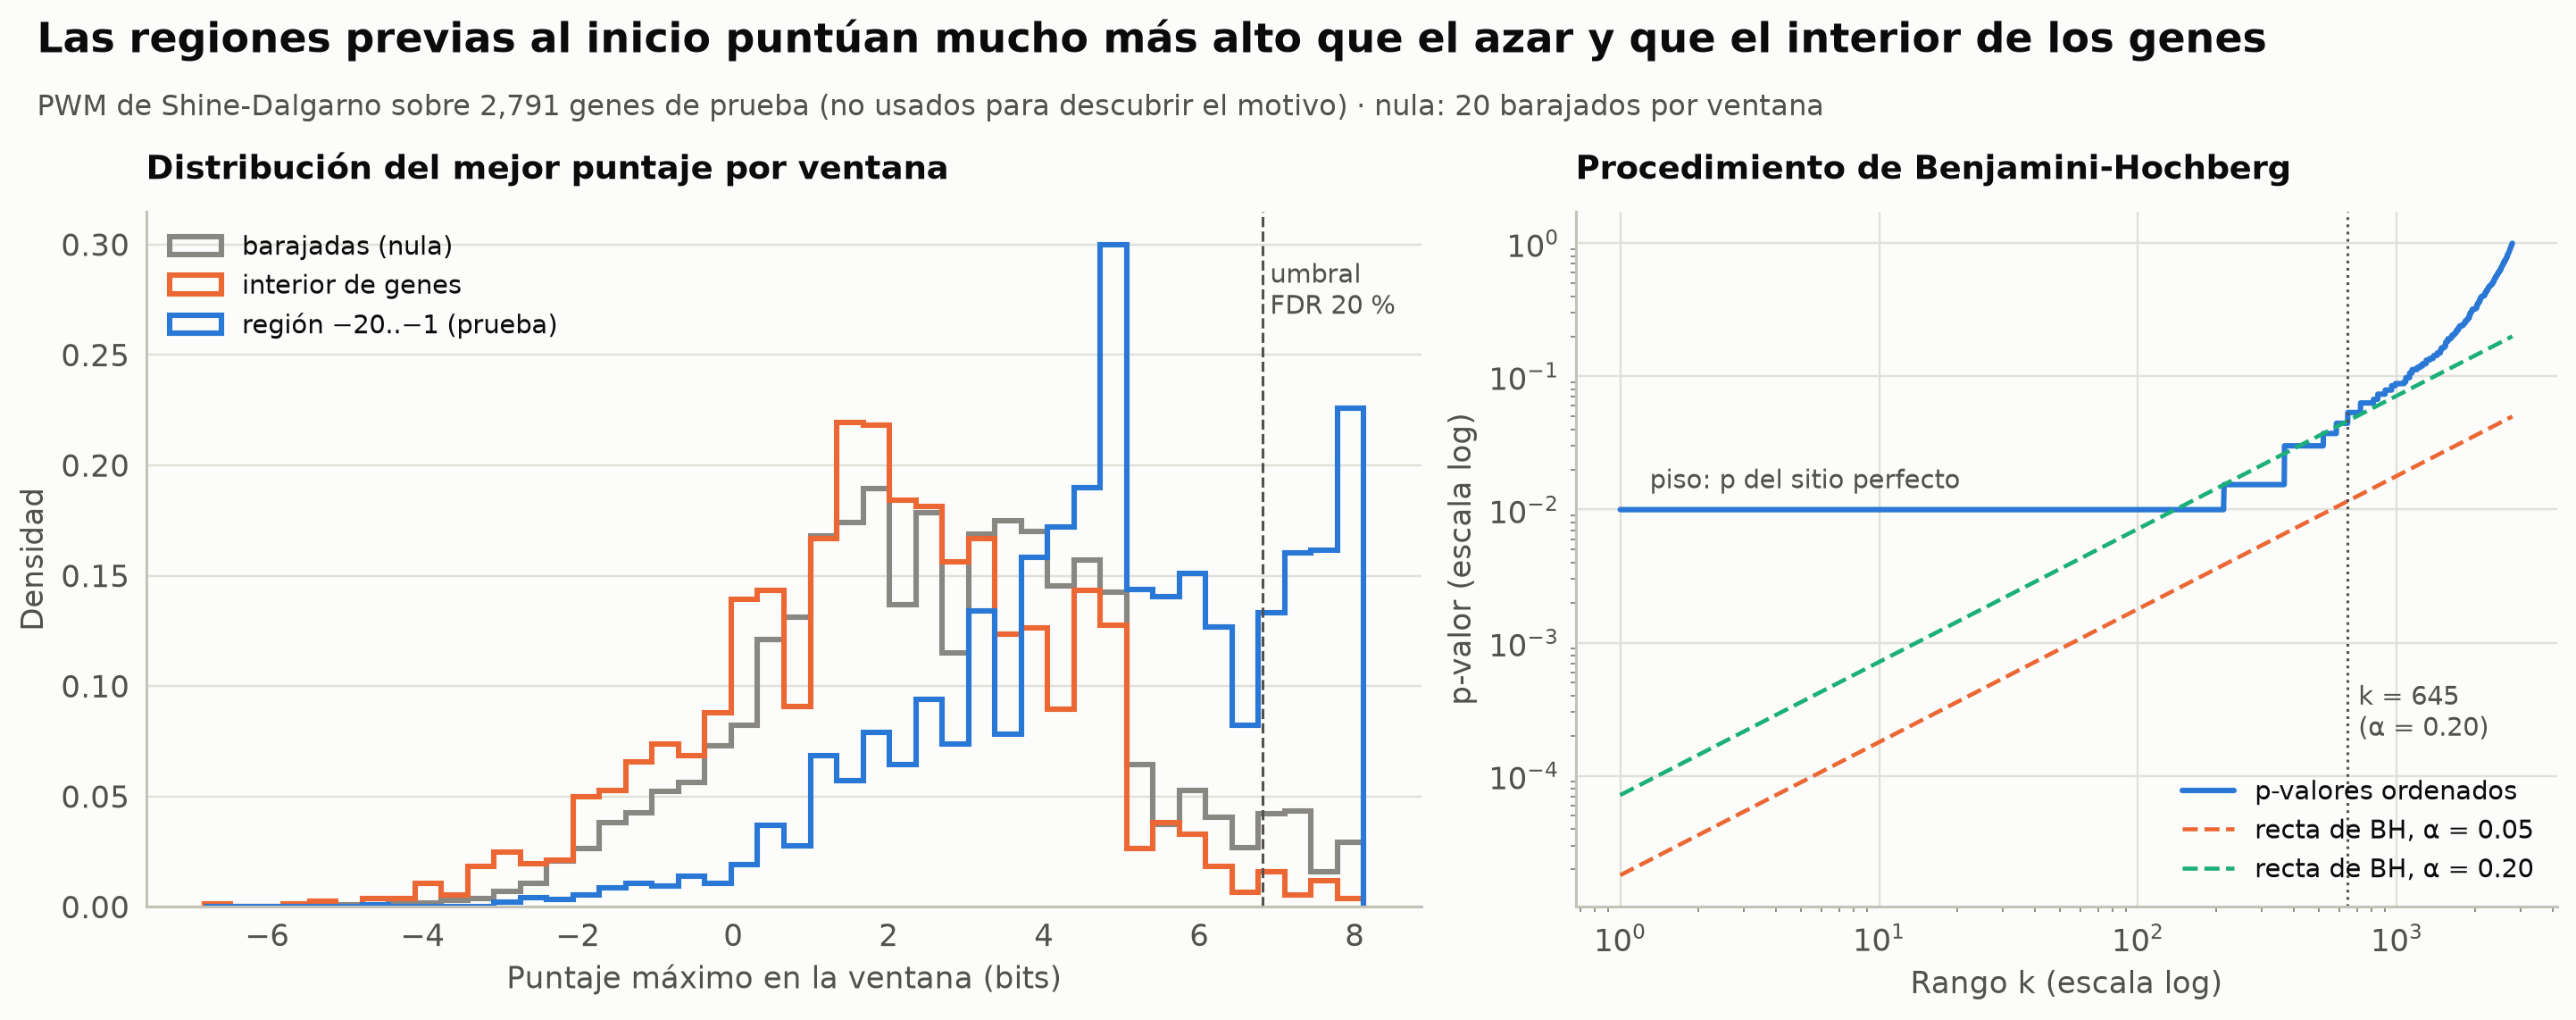

In [23]:
def benjamini_hochberg(p, alpha=0.05):
    """Máscara de pruebas significativas controlando la FDR a nivel alpha."""
    p = np.asarray(p); m = len(p)
    order = np.argsort(p)
    passed = p[order] <= alpha * np.arange(1, m + 1) / m
    k = np.max(np.nonzero(passed)[0]) + 1 if passed.any() else 0
    mask = np.zeros(m, bool); mask[order[:k]] = True
    return mask

sig05 = benjamini_hochberg(p_real, 0.05)
sig = benjamini_hochberg(p_real, 0.20)
thr_fdr = real_max[sig].min() if sig.any() else np.inf
p_floor = empirical_p(np.array([sd_pwm.max(0).sum()]))[0]      # p-valor del puntaje máximo posible
pi0 = min(1.0, np.mean(p_real > 0.5) / 0.5)                     # estimación de Storey de la fracción "nula"
print(f"p-valor más pequeño alcanzable (el sitio perfecto): {p_floor:.4f}  → {np.mean(p_real <= p_floor):.1%} de los genes lo tienen")
print(f"Genes significativos con FDR 5 %:  {sig05.sum():,} de {len(sig05):,}")
print(f"Genes significativos con FDR 20 %: {sig.sum():,} ({sig.mean():.0%}) · puntaje mínimo: {thr_fdr:.2f} bits")
print(f"Fracción de genes con señal SD estimada en conjunto (1 − π0): {1 - pi0:.0%}")
print(f"Contenido de información de la PWM: {information_content(sd_counts).sum():.1f} bits")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), width_ratios=[1.3, 1])
bins = np.linspace(min(null_max.min(), real_max.min()), sd_pwm.max(0).sum() + 0.3, 45)
for data, color, label in [(null_max, ec.MUTED, "barajadas (nula)"), (coding_max, ec.ORANGE, "interior de genes"),
                           (real_max, ec.BLUE, "región −20..−1 (prueba)")]:
    axes[0].hist(data, bins=bins, density=True, histtype="step", linewidth=2, color=color, label=label)
axes[0].axvline(thr_fdr, color=ec.INK_2, lw=1, ls="--")
axes[0].text(thr_fdr + 0.1, axes[0].get_ylim()[1] * 0.93, "umbral\nFDR 20 %", fontsize=9.5, color=ec.INK_2, va="top")
axes[0].set_xlabel("Puntaje máximo en la ventana (bits)"); axes[0].set_ylabel("Densidad")
axes[0].legend(loc="upper left", fontsize=9.5)
axes[0].set_title("Distribución del mejor puntaje por ventana", fontsize=12)

m = len(p_real); k = np.arange(1, m + 1)
axes[1].plot(k, np.sort(p_real), color=ec.BLUE, lw=2, label="p-valores ordenados")
axes[1].plot(k, 0.05 * k / m, color=ec.ORANGE, lw=1.5, ls="--", label="recta de BH, α = 0.05")
axes[1].plot(k, 0.20 * k / m, color=ec.AQUA, lw=1.5, ls="--", label="recta de BH, α = 0.20")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("Rango k (escala log)"); axes[1].set_ylabel("p-valor (escala log)")
axes[1].axvline(sig.sum(), color=ec.INK_2, lw=1, ls=":")
axes[1].text(sig.sum() * 1.1, 2e-4, f"k = {sig.sum()}\n(α = 0.20)", fontsize=9.5, color=ec.INK_2)
axes[1].text(1.3, p_floor * 1.3, "piso: p del sitio perfecto", fontsize=9.5, color=ec.INK_2, va="bottom")
axes[1].legend(loc="lower right", fontsize=9.5); axes[1].grid(True, axis="both")
axes[1].set_title("Procedimiento de Benjamini-Hochberg", fontsize=12)
ec.fig_title(fig, "Las regiones previas al inicio puntúan mucho más alto que el azar y que el interior de los genes",
             f"PWM de Shine-Dalgarno sobre {len(real_max):,} genes de prueba (no usados para descubrir el motivo) · nula: 20 barajados por ventana")
plt.show()

> 🔎 **Qué observamos.** La curva de las ventanas del interior de los genes (naranja) queda incluso algo **por
> debajo** de la de las barajadas (gris): dentro de los genes no sobran secuencias tipo SD. La curva azul, en cambio,
> está claramente desplazada hacia la derecha: la región previa al inicio está enriquecida en el motivo. Si
> estimamos la fracción de genes "nulos" a partir de los p-valores grandes (el estimador $\pi_0$ de Storey: con
> genes sin señal, los p-valores se reparten uniformemente, así que los que superan 0.5 deberían ser la mitad de los
> nulos), unos **dos tercios de los genes** llevan señal de Shine-Dalgarno.
>
> Y sin embargo, **con FDR del 5 % no podemos señalar ni un solo gen concreto.** Mire el panel derecho: la curva
> de p-valores tiene un **piso** en ~0.01. Ese es el p-valor del mejor sitio posible (`AAGGAG` perfecto): aun así, en
> 1 de cada 100 ventanas barajadas de 20 nt aparece un sitio igual de bueno. Para que Benjamini-Hochberg aceptara
> genes con $p = 0.01$ harían falta cientos de ellos a ese nivel. Sólo relajando la FDR al 20 % aparecen
> descubrimientos individuales.

### ¿Por qué? Porque el motivo tiene poca información

Recuerde la regla de la sección 5: un motivo de $R$ bits aparece al azar una vez cada $\approx 2^{R}$ posiciones.
Nuestra PWM de SD tiene sólo unos **4 bits** (compárelos con los 9 del ejemplo didáctico): una coincidencia casual
cada ~16 posiciones, casi una por ventana. Para que un sitio fuera significativo **por sí solo** en una ventana de
15 posiciones, entre ~2 800 genes y con FDR del 5 %, necesitaríamos aproximadamente

$$
R \;\gtrsim\; \log_2 \frac{15 \times 2\,800}{0.05} \;\approx\; 20 \text{ bits.}
$$

Esta es una lección general, no un defecto del método: **la significancia estadística de un sitio individual está
limitada por la información del motivo**. La SD es una señal débil que el ribosoma combina con otras (la distancia
al codón de inicio, la estructura secundaria del ARNm, el propio codón de inicio). Los motivos que sí se pueden
detectar uno a uno en un genoma (sitios de restricción largos, sitios de CRISPR, algunos factores con sitios
palindrómicos largos) tienen muchos más bits.

> ✅ **Compruebe su comprensión.** Si alargamos la ventana de búsqueda de 20 a 100 nt antes de cada gen, ¿mejora o
> empeora la significancia de la mejor SD? *(Empeora: hay ~5 veces más posiciones donde el azar puede producir un
> buen puntaje, así que el p-valor del máximo crece.)*

## 13. 🧪 Escaneo del genoma completo: los sitios se acumulan justo antes del codón de inicio

Hasta aquí miramos regiones que ya sabíamos que eran interesantes. El uso real de una PWM es el inverso: **recorrer un
genoma entero** (ambas hebras, 9.3 millones de ventanas) y preguntar dónde hay sitios.

Aquí el umbral se fija **por posición**: barajamos el genoma completo, lo escaneamos igual, y elegimos el puntaje que
sólo el 0.1 % de las ventanas barajadas alcanza ($p = 10^{-3}$ por posición). Aun así esperamos **miles** de
coincidencias por azar (el 0.1 % de 9.3 millones son ~9 300): es el precio de buscar un motivo corto en un genoma
largo. La pregunta interesante es **dónde** caen las coincidencias reales respecto de los genes.

In [24]:
t0 = time.perf_counter()
COMP_INT = np.array([3, 2, 1, 0, 4], dtype=np.int8)       # A↔T, C↔G, N→N
g_rc_int = COMP_INT[g_int[::-1]]
scores_plus = scan(g_int, sd_pwm)
scores_minus = scan(g_rc_int, sd_pwm)
null_genome = scan(np.random.default_rng(3).permutation(g_int), sd_pwm)
THR = np.quantile(null_genome, 1 - 1e-3)
null_rate = np.mean(null_genome >= THR)                    # los puntajes son discretos: la tasa real no es exactamente 0.001
hits_plus = scores_plus >= THR
hits_minus = scores_minus >= THR
print(f"Escaneo de {2 * len(scores_plus):,} ventanas en {time.perf_counter() - t0:.1f} s")
print(f"Umbral (p ≈ 1e-3 por posición): S ≥ {THR:.2f} bits · tasa nula real: {null_rate:.2e}")
print(f"Coincidencias: {hits_plus.sum() + hits_minus.sum():,} (esperadas por azar ≈ {null_rate * 2 * len(scores_plus):,.0f})")

Escaneo de 9,283,294 ventanas en 0.2 s
Umbral (p ≈ 1e-3 por posición): S ≥ 6.81 bits · tasa nula real: 1.23e-03
Coincidencias: 9,844 (esperadas por azar ≈ 11,414)


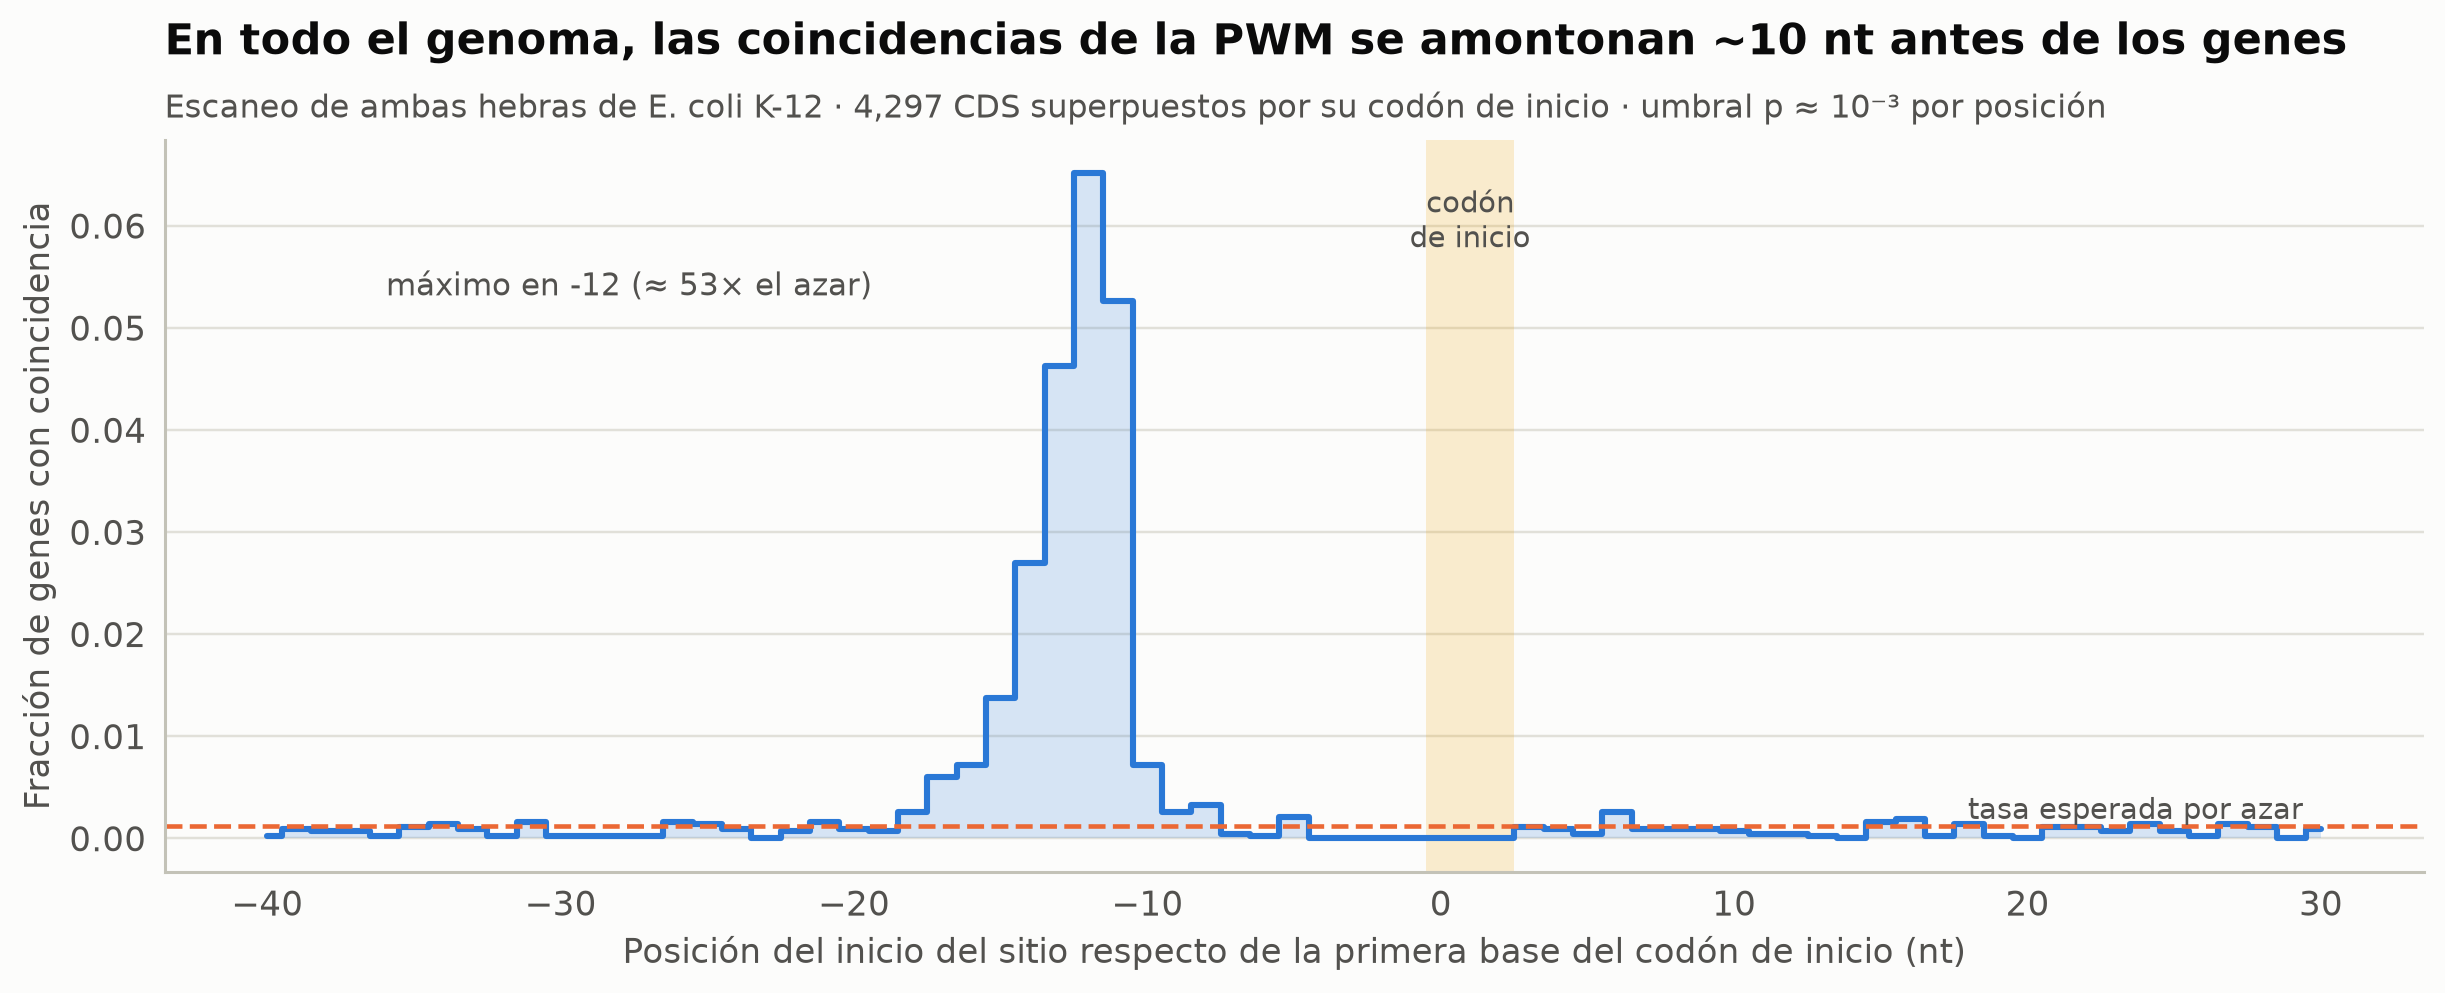

Genes con al menos una coincidencia que empieza entre −20 y −6: 23%


In [25]:
# Perfil "metagénico": tasa de coincidencias en cada posición relativa al codón de inicio, promediada sobre todos los genes
OFFSETS = np.arange(-40, 31)
starts_plus = (cds.loc[cds["strand"] == "+", "start"].to_numpy() - 1)
starts_minus = G_LEN - cds.loc[cds["strand"] == "-", "end"].to_numpy()       # índice del inicio en el genoma invertido
def meta(hits, starts):
    idx = starts[:, None] + OFFSETS[None, :]
    ok = (idx >= 0) & (idx < len(hits))
    return np.where(ok, hits[np.clip(idx, 0, len(hits) - 1)], False)
M_hits = np.vstack([meta(hits_plus, starts_plus), meta(hits_minus, starts_minus)])
rate = M_hits.mean(axis=0)
peak = OFFSETS[np.argmax(rate)]
in_window = M_hits[:, (OFFSETS >= -20) & (OFFSETS <= -W_SD)].any(axis=1).mean()

fig, ax = plt.subplots(figsize=(11, 4.4))
ax.fill_between(OFFSETS, rate, color=ec.BLUE, alpha=0.18, lw=0, step="mid")
ax.step(OFFSETS, rate, where="mid", color=ec.BLUE, lw=2)
ax.axhline(null_rate, color=ec.ORANGE, lw=1.5, ls="--")
ax.text(OFFSETS[-1], null_rate, "tasa esperada por azar  ", ha="right", va="bottom", fontsize=9.5, color=ec.INK_2)
ax.axvspan(-0.5, 2.5, color=ec.YELLOW, alpha=0.18, lw=0)
ax.text(1, rate.max() * 0.98, "codón\nde inicio", ha="center", va="top", fontsize=9.5, color=ec.INK_2)
ax.annotate(f"máximo en {peak} (≈ {rate.max() / null_rate:.0f}× el azar)", (peak, rate.max()), xytext=(-230, -40),
            textcoords="offset points", fontsize=10, color=ec.INK_2, arrowprops=dict(arrowstyle="-", color=ec.MUTED))
ax.set_xlabel("Posición del inicio del sitio respecto de la primera base del codón de inicio (nt)")
ax.set_ylabel("Fracción de genes con coincidencia")
ec.title(ax, "En todo el genoma, las coincidencias de la PWM se amontonan ~10 nt antes de los genes",
         f"Escaneo de ambas hebras de E. coli K-12 · {len(M_hits):,} CDS superpuestos por su codón de inicio · umbral p ≈ 10⁻³ por posición")
plt.show()
print(f"Genes con al menos una coincidencia que empieza entre −20 y −{W_SD}: {in_window:.0%}")

> 🔎 **Qué observamos.** Lejos de los genes, la tasa de coincidencias se parece a la que predice el azar (línea
> naranja). Pero unas diez posiciones antes del codón de inicio se dispara a decenas de veces el azar. Ningún paso del
> escaneo "sabía" dónde estaban los genes: la PWM encontró por su cuenta la región donde el ribosoma necesita su
> señal. Esta es la base de cómo los buscadores de genes procariotas (como los de la Lección 1.2) refinan cuál de los
> posibles ATG es el verdadero inicio: el que tiene una buena SD a la distancia correcta.

### Explorador interactivo: el perfil de puntajes en el operón *thr*

El operón de la treonina está al principio del genoma de *E. coli* (hebra +): un péptido líder (*thrL*) y tres genes
(*thrA*, *thrB*, *thrC*), seguidos de *yaaX*. Aquí usamos un umbral **más permisivo**, $p \approx 10^{-2}$ por
posición (la línea punteada superior marca el estricto, $10^{-3}$). Pase el cursor por los puntos: verá la secuencia
del sitio, su puntaje, su p-valor por posición y a qué distancia queda el siguiente codón de inicio. Use el zoom para
ver el detalle de cada gen.

> 🤔 **Antes de ejecutar, prediga.** En 5 300 posiciones y con $p = 0.01$ por posición, ¿cuántas coincidencias
> esperaría sólo por azar?

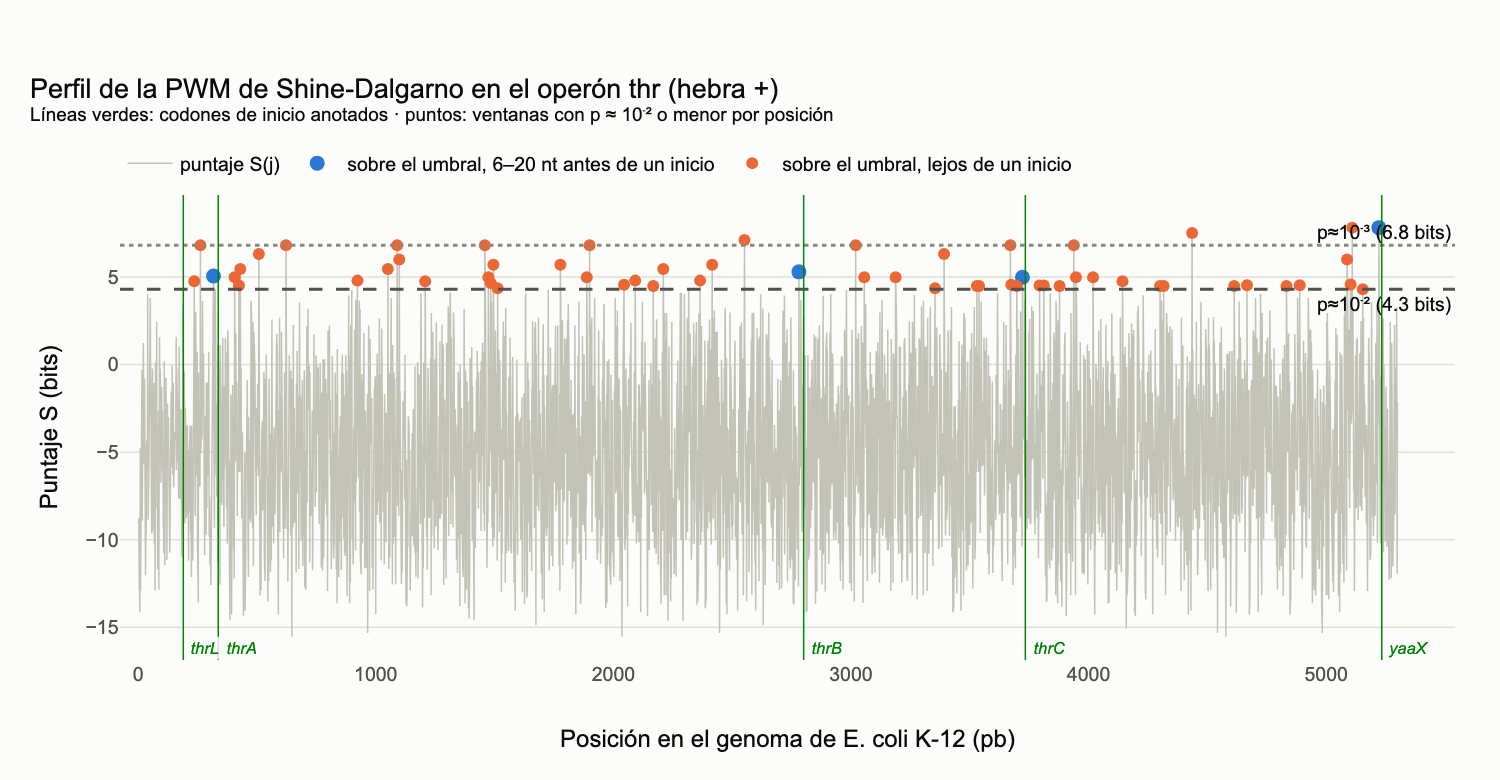

Coincidencias en la región: 59 · esperadas por azar ≈ 54 · justo antes de un inicio: 4
  thrL  mejor sitio ACAGAG en -18 · S =  1.04 · p = 0.0671
  thrA  mejor sitio AAGGTA en -20 · S =  5.06 · p = 0.0049
  thrB  mejor sitio ATGGAA en -20 · S =  5.29 · p = 0.0037
  thrC  mejor sitio CTGGAA en -12 · S =  4.99 · p = 0.0054
  yaaX  mejor sitio AAGGAG en -12 · S =  7.82 · p = 0.0002


In [26]:
REGION = (0, 5_300)
x = np.arange(*REGION)
prof = scores_plus[REGION[0]:REGION[1]]
region_genes = cds[(cds["strand"] == "+") & (cds["start"] <= REGION[1])]
gene_starts = region_genes["start"].to_numpy() - 1
null_sorted_g = np.sort(null_genome)
def p_position(s):
    return (len(null_sorted_g) - np.searchsorted(null_sorted_g, s, side="left") + 1) / (len(null_sorted_g) + 1)

THR_LOOSE = np.quantile(null_genome, 1 - 1e-2)           # umbral permisivo: p ≈ 0.01 por posición
rate_loose = np.mean(null_genome >= THR_LOOSE)
hit_x = x[prof >= THR_LOOSE]
hit_s = prof[prof >= THR_LOOSE]
def next_start(h):
    d = gene_starts - h
    d = d[d >= 0]
    return f"{d.min()} nt antes del inicio de {region_genes['gene'].to_numpy()[np.argmin(np.where(gene_starts - h >= 0, gene_starts - h, 1e9))]}" if len(d) else "ningún inicio posterior"
hover = [f"<b>{genome[h:h + W_SD]}</b> en {h + 1:,}<br>S = {s:.2f} bits · p = {p_position(s):.1e}<br>{next_start(h)}"
         for h, s in zip(hit_x, hit_s)]
near = np.array([np.any((gene_starts - h >= W_SD) & (gene_starts - h <= 20)) for h in hit_x], dtype=bool)

fig = go.Figure()
fig.add_scatter(x=x + 1, y=prof, mode="lines", line=dict(color=ec.BASELINE, width=1), name="puntaje S(j)",
                hovertemplate="posición %{x:,}<br>S = %{y:.2f} bits<extra></extra>")
fig.add_scatter(x=hit_x[near] + 1, y=hit_s[near], mode="markers", marker=dict(color=ec.BLUE, size=10),
                name=f"sobre el umbral, {W_SD}–20 nt antes de un inicio", text=np.array(hover)[near], hovertemplate="%{text}<extra></extra>")
fig.add_scatter(x=hit_x[~near] + 1, y=hit_s[~near], mode="markers", marker=dict(color=ec.ORANGE, size=8),
                name="sobre el umbral, lejos de un inicio", text=np.array(hover)[~near], hovertemplate="%{text}<extra></extra>")
fig.add_hline(y=THR, line_dash="dot", line_color=ec.MUTED, annotation_text=f"p≈10⁻³ ({THR:.1f} bits)",
              annotation_position="top right")
fig.add_hline(y=THR_LOOSE, line_dash="dash", line_color=ec.INK_2, annotation_text=f"p≈10⁻² ({THR_LOOSE:.1f} bits)",
              annotation_position="bottom right")
for r in region_genes.itertuples():
    fig.add_vline(x=r.start, line_color=ec.GREEN, line_width=1)
    fig.add_annotation(x=r.start, y=0.0, yref="paper", text=f"<i>{r.gene}</i>", showarrow=False, yanchor="bottom",
                       xanchor="left", xshift=3, font=dict(size=11, color=ec.GREEN), bgcolor="rgba(252,252,251,0.85)")
fig.update_layout(
    title=dict(text="Perfil de la PWM de Shine-Dalgarno en el operón thr (hebra +)"
                    "<br><sup>Líneas verdes: codones de inicio anotados · puntos: ventanas con p ≈ 10⁻² o menor por posición</sup>"),
    xaxis_title="Posición en el genoma de E. coli K-12 (pb)", yaxis_title="Puntaje S (bits)",
    height=520, margin=dict(t=130, r=30),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0))
fig.show()
print(f"Coincidencias en la región: {len(hit_x)} · esperadas por azar ≈ {rate_loose * len(prof):.0f} · "
      f"justo antes de un inicio: {near.sum()}")
for r in region_genes.itertuples():                       # mejor sitio en la ventana −20..−6 de cada gen
    s0 = r.start - 1
    j = int(np.argmax(scores_plus[s0 - 20: s0 - W_SD + 1]))
    best_s = scores_plus[s0 - 20 + j]
    print(f"  {r.gene:5s} mejor sitio {genome[s0 - 20 + j: s0 - 20 + j + W_SD]} en {j - 20:+d} · "
          f"S = {best_s:5.2f} · p = {p_position(best_s):.4f}")

> 🔎 **Qué observamos.** Con el umbral permisivo aparecen coincidencias justo antes de *thrA*, *thrB*, *thrC* y
> *yaaX* (puntos azules; la de *yaaX* es un `AAGGAG` perfecto); la región del péptido líder *thrL* no tiene ninguna
> SD reconocible. Pero el precio es alto:
> alrededor de **cincuenta coincidencias lejos de cualquier inicio** (naranja), casi exactamente las que predice el
> azar para ~5 kb con $p = 0.01$. Con el umbral estricto ($10^{-3}$) desaparece casi todo el ruido… y también casi
> todas las SD verdaderas, que sólo alcanzan $p \approx 0.005$.
>
> Es la lección central del escaneo con PWM de motivos cortos: **un sitio aislado con buen puntaje no basta**. El
> contexto (la distancia a un ATG, la hebra, la conservación entre especies, datos experimentales) es lo que separa
> los sitios funcionales de las coincidencias. Para muchos motivos de factores de transcripción, que tampoco tienen
> muchos bits, el problema es igual de severo.

## ✍️ Ejercicios

**Ejercicio 1 — Una PWM a mano.** Con los sitios `ACG`, `ACG`, `ATG`, `GCG`, pseudoconteo $\alpha = 1$ y fondo uniforme,
calcule la matriz de conteos, $p_{A,1}$, $w_{A,1}$, $w_{T,2}$ y el puntaje de `ACG` y de `GTC`. Verifique con
`count_matrix`, `frequencies`, `pwm_log_odds` y `score_site`.

**Ejercicio 2 — Bits y frecuencia de aparición.** Calcule el contenido de información (sin corrección) de columnas
con frecuencias $(0.25, 0.25, 0.25, 0.25)$, $(0.5, 0.5, 0, 0)$ y $(0.7, 0.1, 0.1, 0.1)$. Si un motivo tuviera 6
columnas del último tipo, ¿cada cuántas posiciones de secuencia uniforme esperaría una "coincidencia" al azar
($\approx 2^{R}$)?

**Ejercicio 3 — La distribución nula exacta.** Si las bases del fondo son independientes con probabilidades
$q_b$, la distribución del puntaje de una ventana es la **convolución** de las distribuciones de cada columna
(cada columna aporta $w_{b,i}$ con probabilidad $q_b$). Redondee los pesos de `sd_pwm` a 0.01 bits, calcule la
distribución exacta convolucionando las 6 columnas con `np.convolve`, y compare su cuantil $1 - 10^{-3}$ con el umbral
empírico `THR` de la sección 13.

**Ejercicio 4 — La idea de MEME: EM en lugar de sorteo.** Programe la versión **EM** del modelo OOPS: en el paso E,
para cada secuencia calcule la probabilidad posterior de cada posición $Z_{n,j} \propto 2^{S_j}$ (normalizada a 1 en
cada secuencia); en el paso M, construya la matriz de conteos **ponderada**: cada ventana suma sus letras con peso
$Z_{n,j}$. Ejecútelo sobre `X_syn` desde una PWM inicial construida con una subcadena de una secuencia (la idea de
MEME de probar muchos puntos de partida) y compare el consenso con el del muestreador de Gibbs.

In [27]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
ex_sites = ["ACG", "ACG", "ATG", "GCG"]
ex_counts = count_matrix(ex_sites)
ex_freq = frequencies(ex_counts, alpha=1.0)
ex_pwm = pwm_log_odds(ex_freq)
print("Conteos (filas A, C, G, T):\n", ex_counts.astype(int))
print(f"p(A,1) = (3 + 0.25) / (4 + 1) = {ex_freq[0, 0]:.3f}  →  w(A,1) = log2({ex_freq[0, 0]:.3f}/0.25) = {ex_pwm[0, 0]:+.3f}")
print(f"w(T,2) = log2(((1 + 0.25)/5)/0.25) = {ex_pwm[3, 1]:+.3f}  (¡cero: vista 1 vez de 4, igual que el fondo!)")
print(f"S(ACG) = {score_site('ACG', ex_pwm):+.3f}   S(GTC) = {score_site('GTC', ex_pwm):+.3f}")

Conteos (filas A, C, G, T):
 [[3 0 0]
 [0 3 0]
 [1 0 4]
 [0 1 0]]
p(A,1) = (3 + 0.25) / (4 + 1) = 0.650  →  w(A,1) = log2(0.650/0.25) = +1.379
w(T,2) = log2(((1 + 0.25)/5)/0.25) = +0.000  (¡cero: vista 1 vez de 4, igual que el fondo!)
S(ACG) = +4.523   S(GTC) = -2.322


In [28]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
for f0 in [(0.25, 0.25, 0.25, 0.25), (0.5, 0.5, 0, 0), (0.7, 0.1, 0.1, 0.1)]:
    f = np.array(f0)
    H = -np.sum([x * np.log2(x) for x in f if x > 0])
    print(f"f = {f0}  →  H = {H:.3f} bits, IC = {2 - H:.3f} bits")
R = 6 * (2 - (-(0.7 * np.log2(0.7) + 3 * 0.1 * np.log2(0.1))))
print(f"Motivo de 6 columnas (0.7, 0.1, 0.1, 0.1): R = {R:.2f} bits  →  una coincidencia cada ~{2 ** R:,.0f} posiciones")

f = (0.25, 0.25, 0.25, 0.25)  →  H = 2.000 bits, IC = 0.000 bits
f = (0.5, 0.5, 0, 0)  →  H = 1.000 bits, IC = 1.000 bits
f = (0.7, 0.1, 0.1, 0.1)  →  H = 1.357 bits, IC = 0.643 bits
Motivo de 6 columnas (0.7, 0.1, 0.1, 0.1): R = 3.86 bits  →  una coincidencia cada ~15 posiciones


Umbral exacto (P ≤ 1e-3): 6.82 bits   ·   umbral empírico por barajado: 6.81 bits


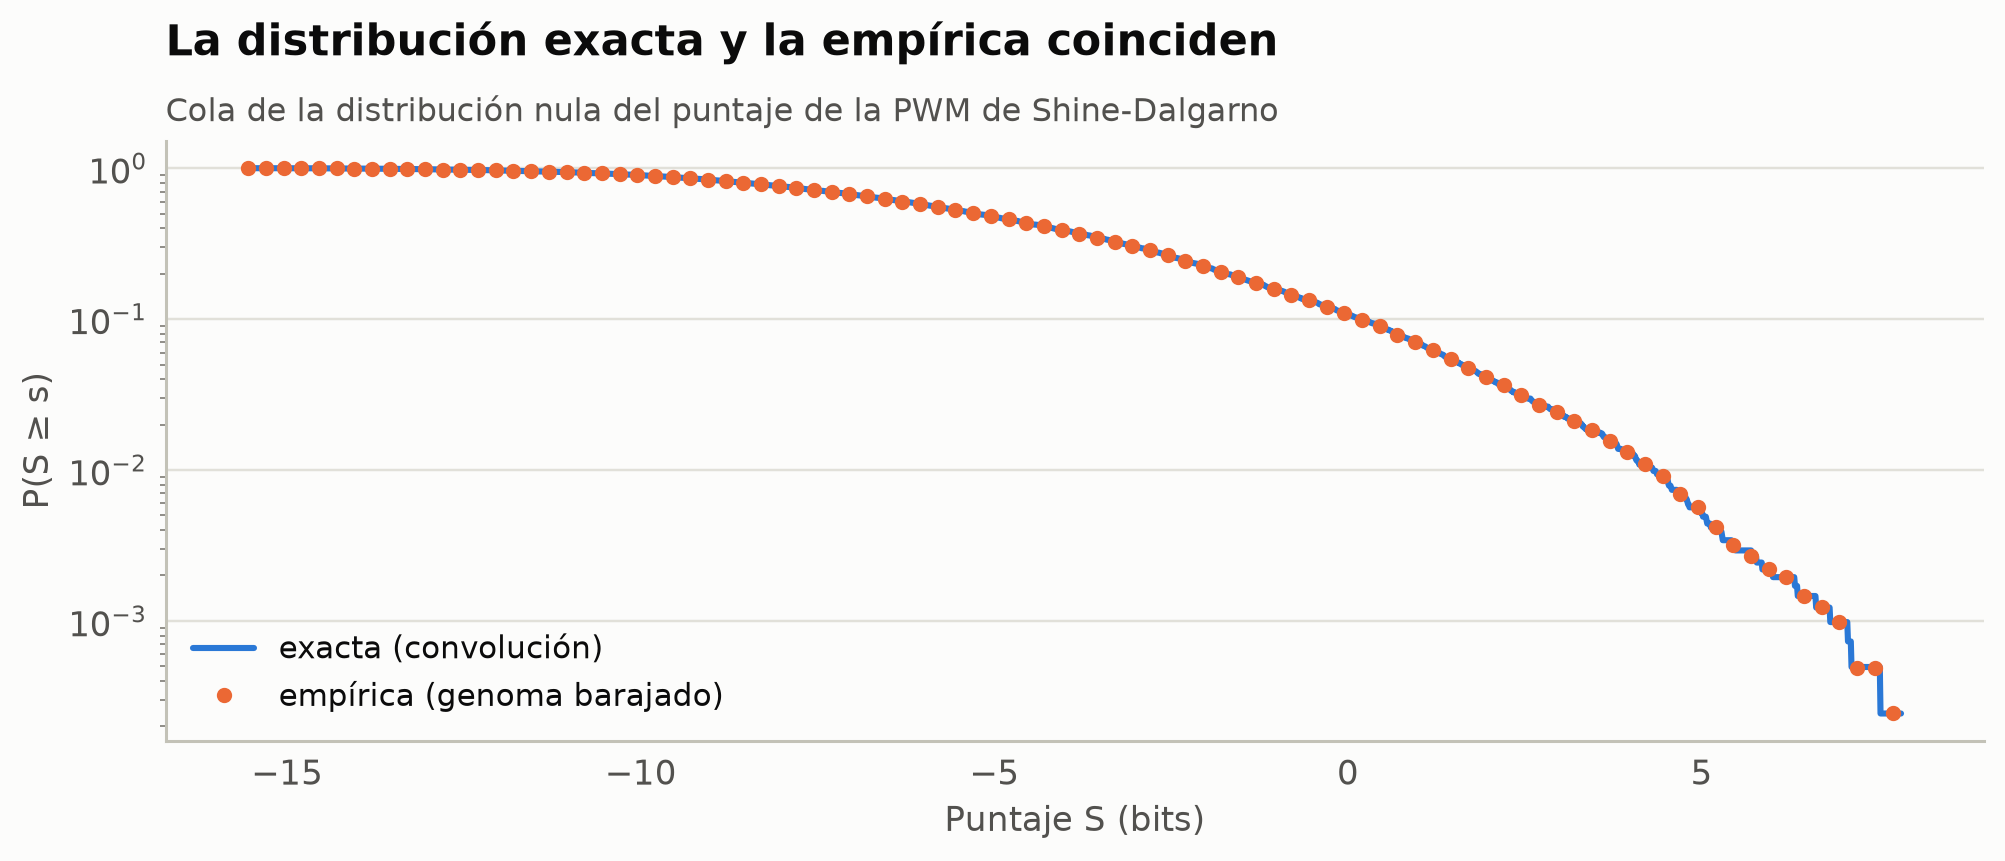

In [29]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
STEP = 0.01
ints = np.round(sd_pwm / STEP).astype(int)                 # pesos como enteros (centésimas de bit)
dist, offset = np.array([1.0]), 0                          # distribución del puntaje acumulado
for i in range(W_SD):
    lo = ints[:, i].min()
    col = np.zeros(ints[:, i].max() - lo + 1)
    for b in range(4):
        col[ints[b, i] - lo] += q_genome[b]
    dist, offset = np.convolve(dist, col), offset + lo
values = (np.arange(len(dist)) + offset) * STEP
tail = np.cumsum(dist[::-1])[::-1]                         # P(S >= valor)
thr_exact = values[np.argmax(tail <= 1e-3)]
print(f"Umbral exacto (P ≤ 1e-3): {thr_exact:.2f} bits   ·   umbral empírico por barajado: {THR:.2f} bits")

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(values, tail, color=ec.BLUE, label="exacta (convolución)")
emp = [np.mean(null_genome >= v) for v in values[::25]]
ax.plot(values[::25], emp, "o", color=ec.ORANGE, ms=4, label="empírica (genoma barajado)")
ax.set_yscale("log"); ax.set_xlabel("Puntaje S (bits)"); ax.set_ylabel("P(S ≥ s)")
ax.legend(loc="lower left")
ec.title(ax, "La distribución exacta y la empírica coinciden", "Cola de la distribución nula del puntaje de la PWM de Shine-Dalgarno")
plt.show()

In [30]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
def em_oops(X, W, start_word, n_iter=30, background=np.full(4, 0.25), alpha=1.0):
    """EM para el modelo OOPS (idea de MEME): responsabilidades suaves en lugar de un sorteo."""
    N, L = X.shape; P = L - W + 1
    windows = X[:, np.arange(P)[:, None] + np.arange(W)]
    counts = count_matrix([start_word]) * 2 + 0.5            # PWM inicial sesgada hacia la palabra de partida
    for _ in range(n_iter):
        pwm = pwm_log_odds(frequencies(counts, background, alpha), background)
        S = pwm[windows, np.arange(W)].sum(axis=2)           # N x P
        Z = np.exp2(S - S.max(axis=1, keepdims=True)); Z /= Z.sum(axis=1, keepdims=True)   # paso E
        counts = np.zeros((4, W))
        for b in range(4):                                   # paso M: conteos ponderados
            counts[b] = ((windows == b) * Z[:, :, None]).sum(axis=(0, 1))
    return counts, Z

# Probar como punto de partida cada subcadena de la primera secuencia y quedarse con la mejor (como MEME)
best_em = None
for j in range(L_SYN - W_SYN + 1):
    c, Z = em_oops(X_syn, W_SYN, syn_seqs[0][j:j + W_SYN], n_iter=15)
    F = float((c * pwm_log_odds(frequencies(c), np.full(4, 0.25))).sum())
    if best_em is None or F > best_em[0]:
        best_em = (F, c, Z)
F, c, Z = best_em
print("Consenso EM:", "".join(BASES[k] for k in c.argmax(0)), f"· F = {F:.0f} bits")
print(f"Secuencias cuya posición más probable es la implantada: {(Z.argmax(1) == true_pos).mean():.0%}")

Consenso EM: GATTACAG · F = 309 bits
Secuencias cuya posición más probable es la implantada: 87%


## 📌 Resumen

* Un **motivo** es un patrón corto y variable que una proteína o un ARN reconoce (SD, caja −10, caja TATA, sitios de
  factores de transcripción). La secuencia consenso lo resume, pero pierde la variabilidad.
* Cadena de construcción: **conteos** $n_{b,i}$ → **frecuencias con pseudoconteos** $p_{b,i} = (n_{b,i} + \alpha q_b)/(N + \alpha)$
  → **PWM** $w_{b,i} = \log_2(p_{b,i}/q_b)$. El puntaje de una secuencia es la **suma de pesos**, un log-odds en bits.
* El **contenido de información** $IC_i = 2 - H_i$ mide cuánto exige cada posición (0 a 2 bits); con pocos sitios hay
  que restar la corrección $e(N) \approx 3/(2 \ln 2 \cdot N)$. El **sequence logo** apila letras de altura
  $f_{b,i} \cdot IC_i$.
* **Descubrir** un motivo sin conocer los sitios es un problema circular que el **muestreador de Gibbs** (sorteo) y
  **EM/MEME** (pesos suaves) resuelven alternando entre "sitios → PWM" y "PWM → sitios". Hay que lanzar varias
  ejecuciones y corregir desfases.
* Con los ~4 300 genes de *E. coli*, el muestreador redescubrió la **secuencia de Shine-Dalgarno**, complementaria al
  extremo 3′ del ARN 16S, a unos 4–9 nt del codón de inicio.
* La **significancia** de un puntaje se juzga contra una distribución nula (secuencias barajadas o la distribución
  exacta), y con muchas pruebas se controla la **FDR** (Benjamini-Hochberg). Un motivo de pocos bits (la SD tiene
  ~4) está claramente enriquecido en conjunto, pero no alcanza para declarar significativo cada sitio por separado:
  en un genoma, un buen puntaje aislado no basta y el contexto decide.

**Próxima lección:** de las PWM a los **perfiles** y los **modelos ocultos de Markov** (HMM), que añaden inserciones
y deleciones al modelo posicional.

## 📚 Para profundizar

* Shine, J. & Dalgarno, L. (1974). The 3′-terminal sequence of *Escherichia coli* 16S ribosomal RNA: complementarity
  to nonsense triplets and ribosome binding sites. *PNAS* 71(4): 1342–1346.
* Schneider, T. D., Stormo, G. D., Gold, L. & Ehrenfeucht, A. (1986). Information content of binding sites on
  nucleotide sequences. *Journal of Molecular Biology* 188(3): 415–431.
* Schneider, T. D. & Stephens, R. M. (1990). Sequence logos: a new way to display consensus sequences.
  *Nucleic Acids Research* 18(20): 6097–6100.
* Lawrence, C. E., Altschul, S. F., Boguski, M. S., Liu, J. S., Neuwald, A. F. & Wootton, J. C. (1993). Detecting
  subtle sequence signals: a Gibbs sampling strategy for multiple alignment. *Science* 262(5131): 208–214.
* Bailey, T. L. & Elkan, C. (1994). Fitting a mixture model by expectation maximization to discover motifs in
  biopolymers. *Proceedings of the Second International Conference on Intelligent Systems for Molecular Biology*
  2: 28–36.
* Benjamini, Y. & Hochberg, Y. (1995). Controlling the false discovery rate: a practical and powerful approach to
  multiple testing. *Journal of the Royal Statistical Society B* 57(1): 289–300.
* Stormo, G. D. (2000). DNA binding sites: representation and discovery. *Bioinformatics* 16(1): 16–23.
* Crooks, G. E., Hon, G., Chandonia, J.-M. & Brenner, S. E. (2004). WebLogo: a sequence logo generator.
  *Genome Research* 14(6): 1188–1190.

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)